# Tutorial 6 - Normal Models

Main question:
How do we model continuous weight data using Normal models, and how do Bayesian Normal models connect to frequentist t-tests?

The tutorial separates:
1. Continuous data and Normal likelihoods
2. Bayesian Normal model workflow
3. Prior predictive checks, diagnostics, and posterior predictive checks
4. Bayesian p-values as model-fit checks
5. Paired data and paired Normal models
6. Frequentist paired tests
7. Robust models using Student-t likelihoods
8. Independent group differences with Normal models
9. Effect size, ROPE, and HDI
10. Frequentist independent / Welch / rank-based tests
11. Unequal variances as a modeling assumption



## Setup

In [ ]:
# Install Preliz only if it cannot be imported correctly

import subprocess
import sys

try:
    import preliz as pz
    print("preliz is already installed and working.")
except ModuleNotFoundError as error:
    print(f"preliz import failed because a dependency is missing: {error.name}")
    print("Installing/upgrading preliz and required dependencies...")

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "preliz",
        "arviz-base",
        "arviz-stats"
    ])

    import preliz as pz
    print("preliz installed and imported successfully.")

from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import pymc as pm
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats

from google.colab import files

az.style.use("arviz-darkgrid")
sns.set_style("darkgrid")

random_seed = 17

HDI_MASS = 0.94
SIGNIFICANCE_ALPHA = 0.05

BAYESIAN_COLOR = "tab:blue"
ROPE_COLOR = "tab:green"
NULL_COLOR = "black"
FREQUENTIST_COLOR = "tab:red"
MODEL_COMPARISON_COLOR = "tab:orange"

preliz import failed because a dependency is missing: preliz
Installing/upgrading preliz and required dependencies...
preliz installed and imported successfully.


## Helper functions

In [ ]:
def load_csv_or_upload(filename):
    """
    Read a CSV file from the current Colab session.
    If the file is not found, ask the user to upload it.
    """

    if Path(filename).exists():
        print(f"Using existing file: {filename}")
        return pd.read_csv(filename)

    print(f"{filename} was not found in the current Colab files.")
    print(f"Please upload {filename}.")

    uploaded = files.upload()

    if filename in uploaded:
        uploaded_filename = filename
    else:
        uploaded_filename = list(uploaded.keys())[0]
        print(f"Using uploaded file: {uploaded_filename}")

    return pd.read_csv(uploaded_filename)


def summarize_hdi(samples, hdi_prob=HDI_MASS):
    """
    Return posterior mean, median, and HDI for a one-dimensional sample array.
    """

    hdi = az.hdi(samples, hdi_prob=hdi_prob)

    return {
        "mean": np.mean(samples),
        "median": np.median(samples),
        "hdi_low": hdi[0],
        "hdi_high": hdi[1],
    }


def posterior_predictive_matrix(idata, var_name, obs_dim="obs"):
    """
    Convert posterior predictive samples to a matrix with shape:
    samples x observations.
    """

    return (
        idata.posterior_predictive[var_name]
        .stack(sample=("chain", "draw"))
        .transpose("sample", obs_dim)
        .values
    )


def plot_observed_vs_replicated_statistic(
    replicated_statistics,
    observed_statistic,
    statistic_name,
    title
):
    """
    Plot a posterior predictive distribution of a statistic and the observed statistic.
    """

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.hist(
        replicated_statistics,
        bins=30,
        density=True,
        alpha=0.65,
        label="posterior predictive statistics"
    )

    ax.axvline(
        observed_statistic,
        color=NULL_COLOR,
        linewidth=2,
        label="observed statistic"
    )

    ax.set_xlabel(statistic_name)
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend()
    plt.show()

## Data 1: Food diet weight data

The dataset contains measurements from the same people before and after six weeks of dieting:

- `pre.weight`: weight before the diet
- `weight6weeks`: weight after six weeks

Weight is continuous and measured in kilograms.

In [ ]:
food_df = load_csv_or_upload("foodDiet_extended.csv")

required_food_columns = ["Person", "gender", "Age", "Height", "pre.weight", "Diet", "weight6weeks"]
missing_food_columns = [col for col in required_food_columns if col not in food_df.columns]

if len(missing_food_columns) > 0:
    raise ValueError(f"Missing required columns: {missing_food_columns}")

food_df = food_df.dropna(subset=["pre.weight", "weight6weeks", "gender"]).copy()

# In this dataset, gender is coded numerically: 0 = female, 1 = male.
food_df["gender_label"] = food_df["gender"].map({0: "female", 1: "male"})
food_df["gender_label"] = food_df["gender_label"].fillna(food_df["gender"].astype(str))

food_df["change"] = (
    food_df["weight6weeks"]
    - food_df["pre.weight"]
)

before = food_df["pre.weight"].to_numpy()
after = food_df["weight6weeks"].to_numpy()
change = food_df["change"].to_numpy()

food_df.head()

Using existing file: foodDiet_extended.csv


,Person,gender,Age,Height,pre.weight,Diet,weight6weeks,gender_label,change
0,1,0,22,159,58.0,1,54.2,female,-3.8
1,2,0,46,192,60.0,1,54.0,female,-6.0
2,3,0,55,170,64.0,1,63.3,female,-0.7
3,4,0,33,171,64.0,1,61.1,female,-2.9
4,5,0,50,170,65.0,1,62.2,female,-2.8


### Plot the pre-diet weight data

/tmp/ipykernel_2651/1706461414.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


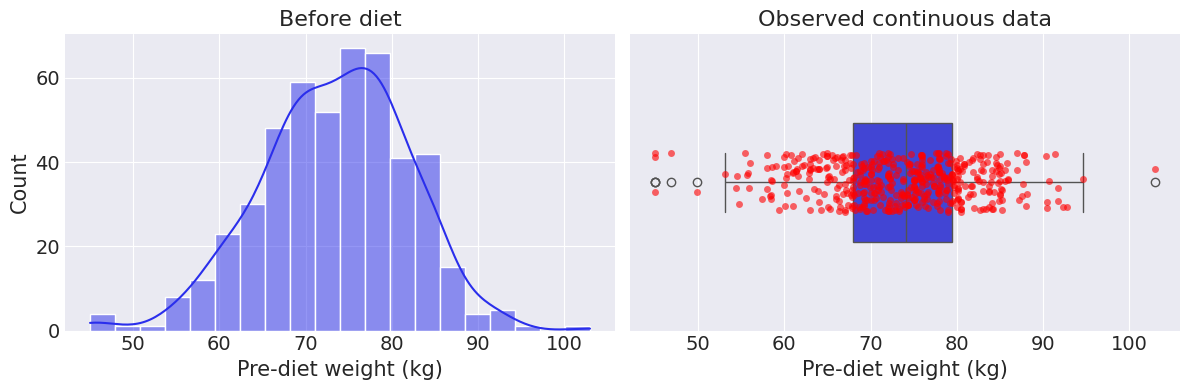

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(before, kde=True, ax=axes[0])
axes[0].set_xlabel("Pre-diet weight (kg)")
axes[0].set_title("Before diet")

sns.boxplot(x=before, ax=axes[1], width=0.4)
sns.stripplot(x=before, ax=axes[1], color="red", alpha=0.6, jitter=True)
axes[1].set_xlabel("Pre-diet weight (kg)")
axes[1].set_title("Observed continuous data")

plt.tight_layout()
plt.show()

## Normal distribution

The Normal distribution is characterized by two parameters:

\[
\mu \quad \text{center / mean}
\]

\[
\sigma \quad \text{spread / standard deviation}
\]

If we model continuous data using a Normal distribution, each parameter needs its own prior.

A common Bayesian Normal model is:

\[
\mu \sim \text{Normal}(\mu_0, \sigma_0)
\]

\[
\sigma \sim \text{HalfNormal}(\sigma_\sigma)
\]

\[
y_i \sim \text{Normal}(\mu, \sigma)
\]

The HalfNormal prior is used because \(\sigma\) cannot be negative.



### Explore Normal priors in real data units

/tmp/ipykernel_2651/684042888.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


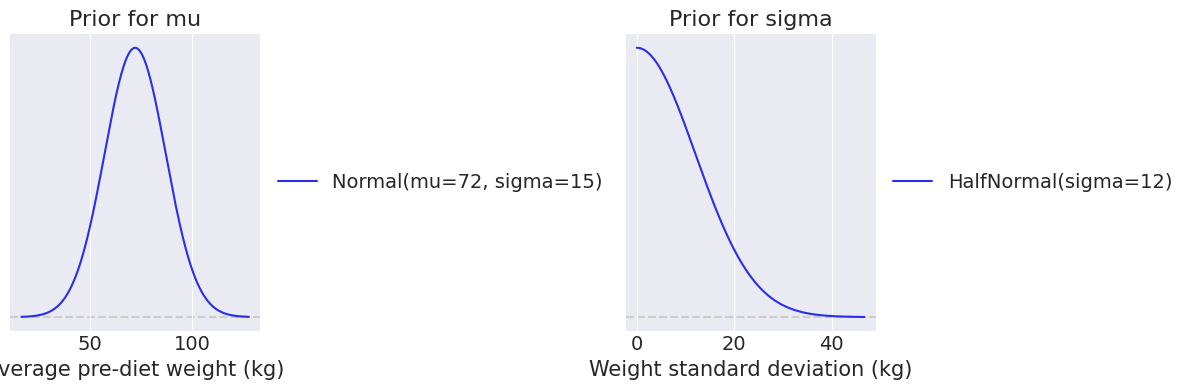

In [ ]:
# Weight is measured in kilograms.
# These priors are chosen in kilograms.

mu_prior_mean = 72
mu_prior_sigma = 15
sigma_prior_sigma = 12

mu_prior = pz.Normal(mu_prior_mean, mu_prior_sigma)
sigma_prior = pz.HalfNormal(sigma_prior_sigma)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mu_prior.plot_pdf(ax=axes[0])
axes[0].set_title("Prior for mu")
axes[0].set_xlabel("Average pre-diet weight (kg)")

sigma_prior.plot_pdf(ax=axes[1])
axes[1].set_title("Prior for sigma")
axes[1].set_xlabel("Weight standard deviation (kg)")

plt.tight_layout()
plt.show()

## Model 1: Bayesian Normal model for one continuous outcome

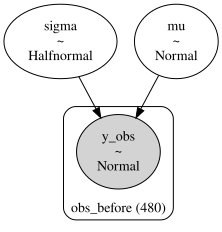

In [ ]:
coords_food_pre = {"obs_before": np.arange(len(before))}

with pm.Model(coords=coords_food_pre) as normal_before_model:

    mu = pm.Normal("mu", mu=mu_prior_mean, sigma=mu_prior_sigma)
    sigma = pm.HalfNormal("sigma", sigma=sigma_prior_sigma)

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=before, dims="obs_before")

pm.model_to_graphviz(normal_before_model)

### Prior predictive check

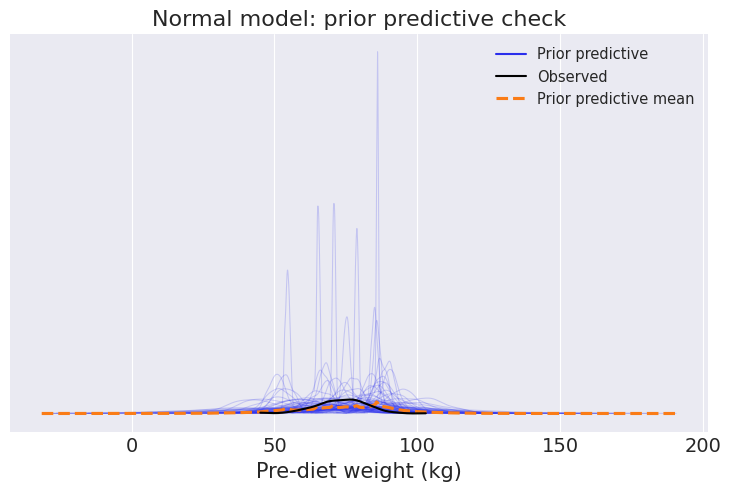

In [ ]:
with normal_before_model:
    idata_normal_before_prior = pm.sample_prior_predictive(
        samples=1000, random_seed=random_seed)

az.plot_ppc(idata_normal_before_prior,group="prior",
            observed=True, num_pp_samples=100, random_seed=random_seed)

plt.title("Normal model: prior predictive check")
plt.xlabel("Pre-diet weight (kg)")
plt.show()

### Sample posterior

In [ ]:
with normal_before_model:
    idata_normal_before = pm.sample(
        draws=1000,
        chains=4,
        random_seed=random_seed
    )

# Add the prior and prior predictive groups to the same InferenceData object.
idata_normal_before.extend(idata_normal_before_prior)

idata_normal_before

Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

### Diagnostics

In [ ]:
az.summary(
    idata_normal_before,
    var_names=["mu", "sigma"],
    kind="diagnostics"
)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.006,0.006,4275.0,3084.0,1.0
sigma,0.004,0.004,4194.0,2896.0,1.0


/tmp/ipykernel_2651/3134549699.py:14: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.7)


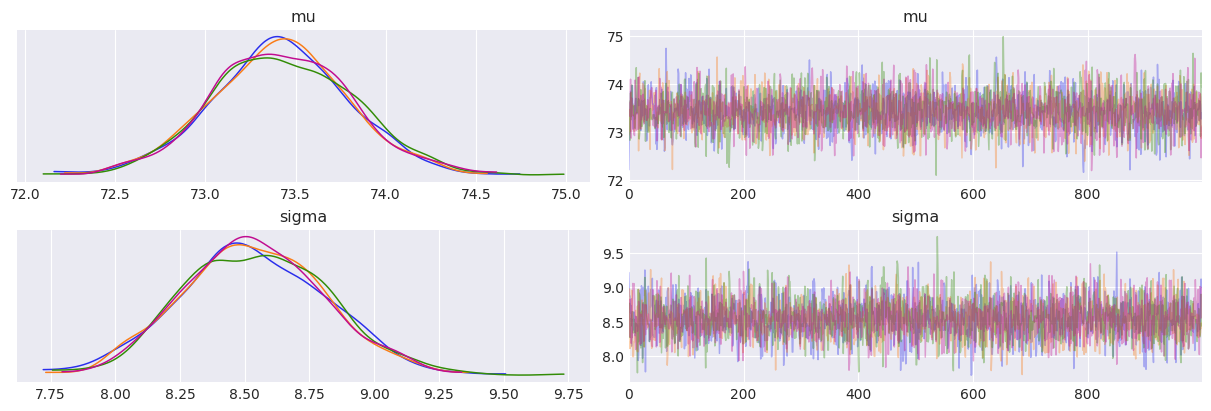

Number of divergences: 0


In [ ]:
az.plot_trace(
    idata_normal_before,
    var_names=["mu", "sigma"],
    compact=False
)

plt.subplots_adjust(hspace=0.7)
plt.show()

normal_before_divergences = idata_normal_before.sample_stats["diverging"].sum().values
print(f"Number of divergences: {normal_before_divergences}")

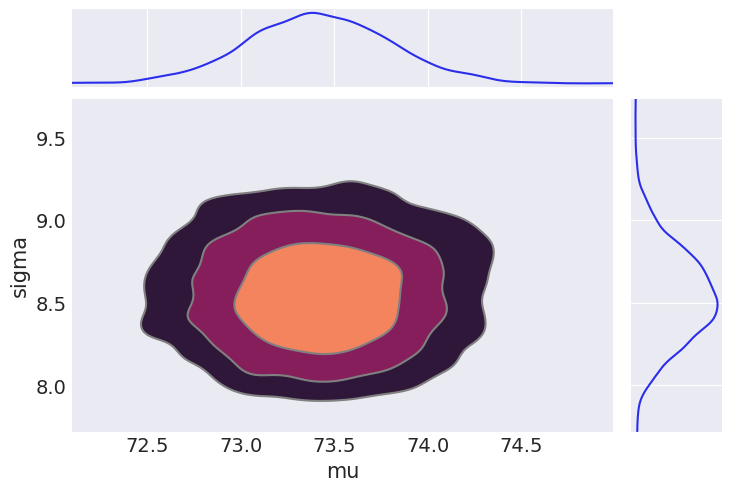

In [ ]:
az.plot_pair(
    idata_normal_before,
    var_names=["mu", "sigma"],
    kind="kde",
    marginals=True
)

plt.show()

### Posterior

In [ ]:
az.summary(
    idata_normal_before,
    var_names=["mu", "sigma"],
    kind="stats",
    hdi_prob=HDI_MASS
).round(2)

,mean,sd,hdi_3%,hdi_97%
mu,73.42,0.38,72.68,74.14
sigma,8.54,0.28,8.04,9.07


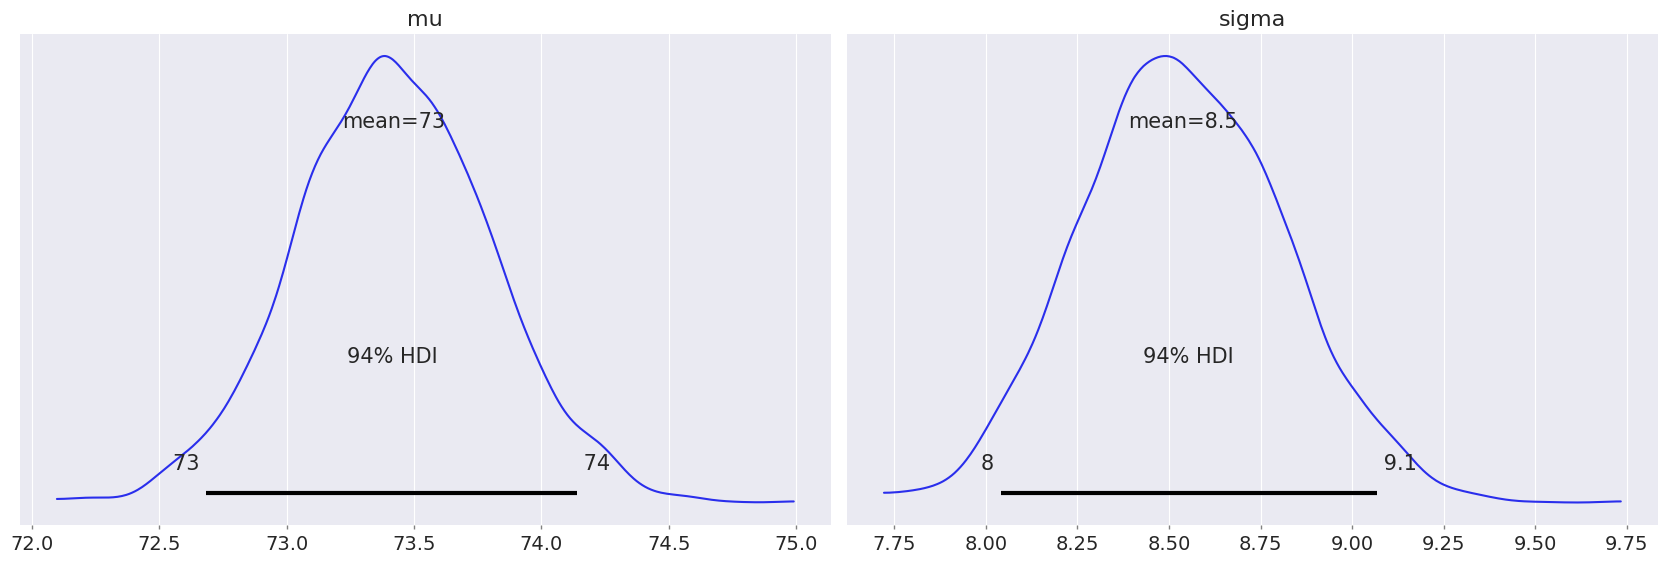

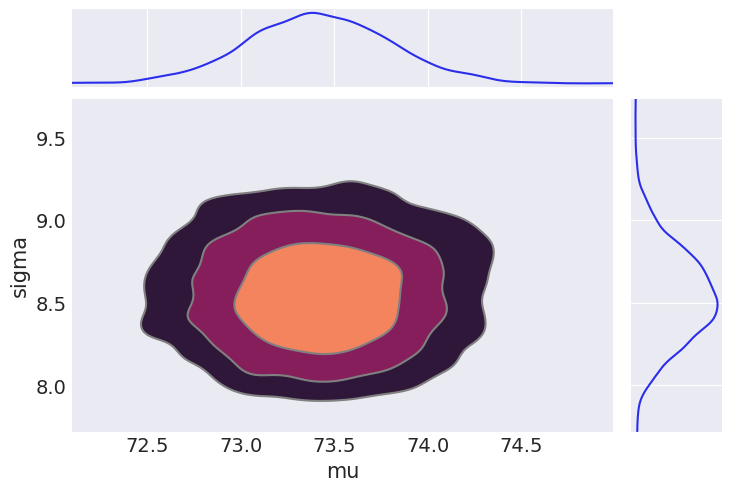

In [ ]:
az.plot_posterior(
    idata_normal_before,
    var_names=["mu", "sigma"],
    hdi_prob=HDI_MASS
)

plt.show()



### Posterior predictive check

Output()

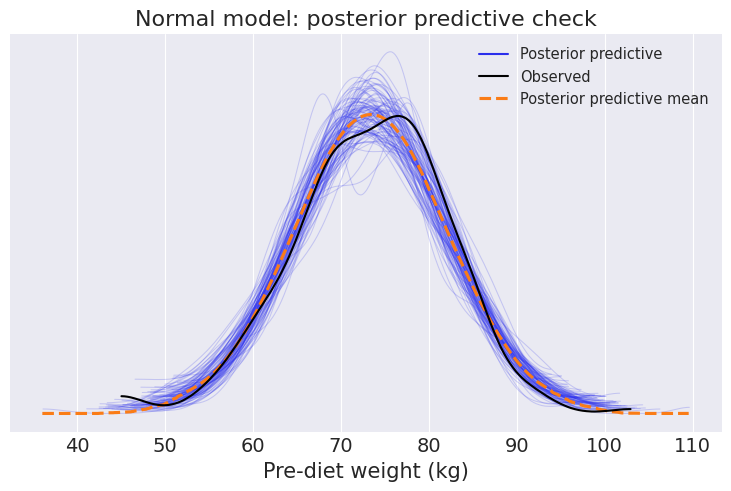

In [ ]:
with normal_before_model:
    idata_normal_before = pm.sample_posterior_predictive(
        idata_normal_before,
        var_names=["y_obs"],
        random_seed=random_seed,
        extend_inferencedata=True
    )

az.plot_ppc(
    idata_normal_before,
    group="posterior",
    observed=True,
    num_pp_samples=100,
    random_seed=random_seed
)

plt.title("Normal model: posterior predictive check")
plt.xlabel("Pre-diet weight (kg)")
plt.show()

## Bayesian p-value as a model-fit check

A Bayesian p-value here is based on the posterior predictive distribution.
It is used as a model-fit check, not as a frequentist significance test.

We compare an observed statistic to the same statistic computed on replicated datasets.

Observed mean: 73.43 kg
Bayesian p-value for the mean: 0.506


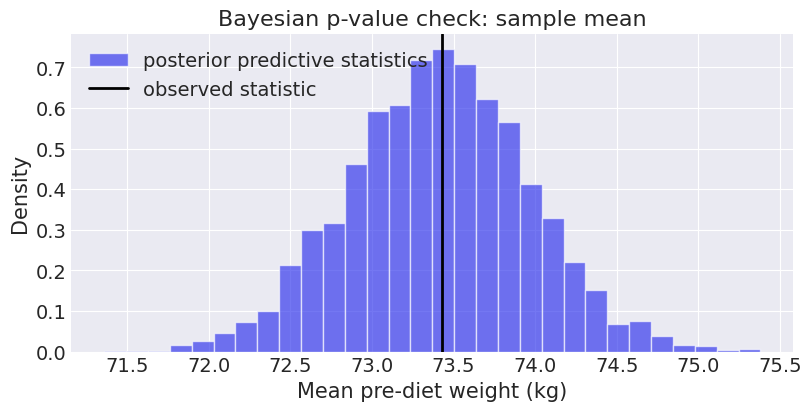

Observed SD: 8.52 kg
Bayesian p-value for the SD: 0.489


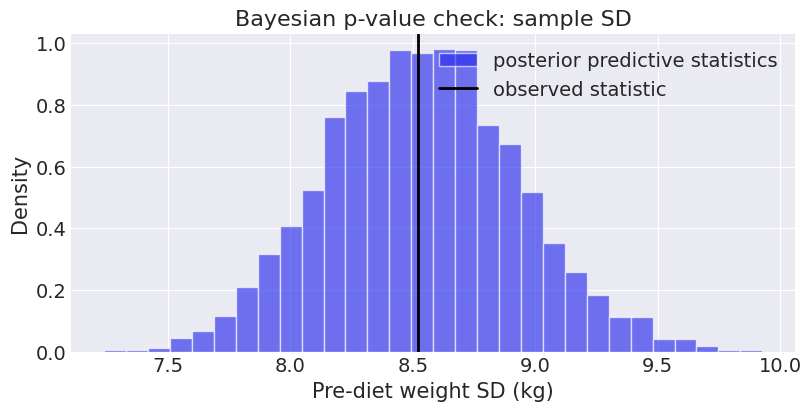

In [ ]:
# Bayesian p value for the sample mean
normal_before_ppc = posterior_predictive_matrix(
    idata=idata_normal_before,
    var_name="y_obs",
    obs_dim="obs_before")

observed_mean_before = before.mean()
replicated_means_before = normal_before_ppc.mean(axis=1)

bayesian_p_value_mean = np.mean(replicated_means_before <= observed_mean_before)

print(f"Observed mean: {observed_mean_before:.2f} kg")
print(f"Bayesian p-value for the mean: {bayesian_p_value_mean:.3f}")

plot_observed_vs_replicated_statistic(
    replicated_statistics=replicated_means_before,
    observed_statistic=observed_mean_before,
    statistic_name="Mean pre-diet weight (kg)",
    title="Bayesian p-value check: sample mean")

# Bayesian p value for the sample std
observed_sd_before = before.std(ddof=1)
replicated_sds_before = normal_before_ppc.std(axis=1, ddof=1)

bayesian_p_value_sd = np.mean(replicated_sds_before <= observed_sd_before)

print(f"Observed SD: {observed_sd_before:.2f} kg")
print(f"Bayesian p-value for the SD: {bayesian_p_value_sd:.3f}")

plot_observed_vs_replicated_statistic(
    replicated_statistics=replicated_sds_before,
    observed_statistic=observed_sd_before,
    statistic_name="Pre-diet weight SD (kg)",
    title="Bayesian p-value check: sample SD")

# Paired data

The food diet data are paired because each person was measured before and after six weeks.

\[
\text{change}_i = \text{after}_i - \text{before}_i
\]

The paired question is:

> Is the average within-person weight change different from zero?

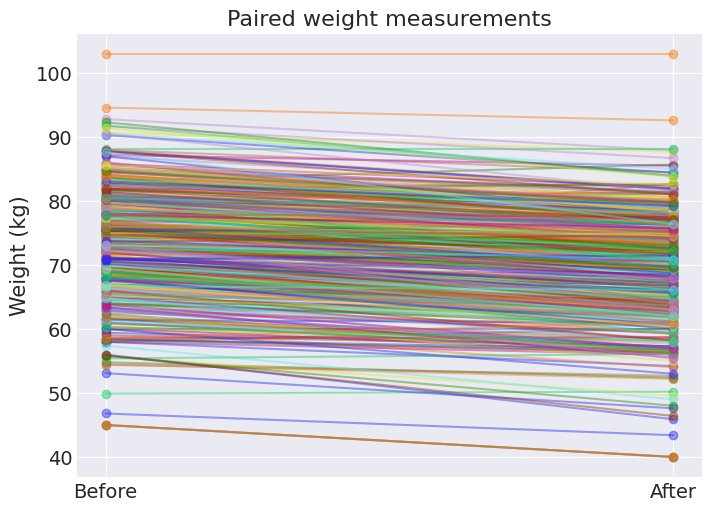

/tmp/ipykernel_2651/3698289842.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


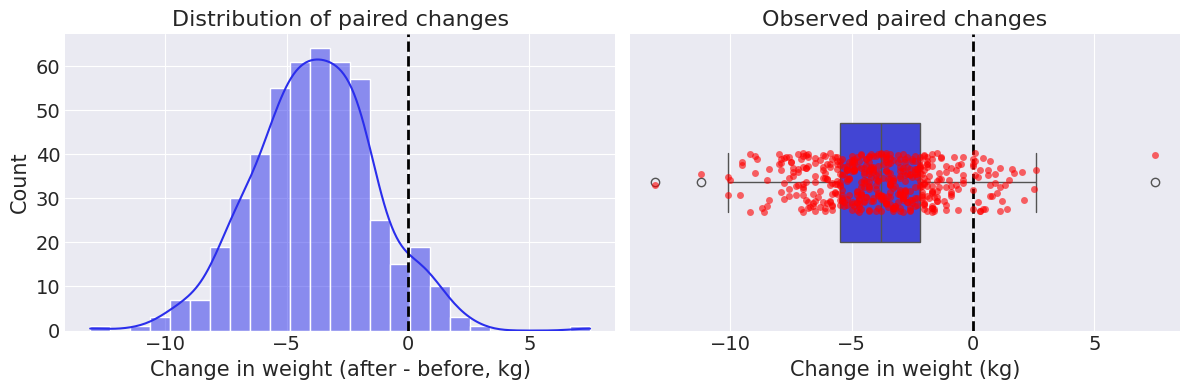

In [ ]:
plt.figure(figsize=(7, 5))

for subject_index, row in food_df.iterrows():
    plt.plot(
        [0, 1],
        [row["pre.weight"], row["weight6weeks"]],
        marker="o",
        alpha=0.45
    )

plt.xticks([0, 1], ["Before", "After"])
plt.ylabel("Weight (kg)")
plt.title("Paired weight measurements")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(change, kde=True, ax=axes[0])
axes[0].axvline(0, color=NULL_COLOR, linestyle="--", linewidth=2)
axes[0].set_xlabel("Change in weight (after - before, kg)")
axes[0].set_title("Distribution of paired changes")

sns.boxplot(x=change, ax=axes[1], width=0.4)
sns.stripplot(x=change, ax=axes[1], color="red", alpha=0.6, jitter=True)
axes[1].axvline(0, color=NULL_COLOR, linestyle="--", linewidth=2)
axes[1].set_xlabel("Change in weight (kg)")
axes[1].set_title("Observed paired changes")

plt.tight_layout()
plt.show()

## Model 2: Bayesian paired Normal model

/tmp/ipykernel_2651/131956903.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


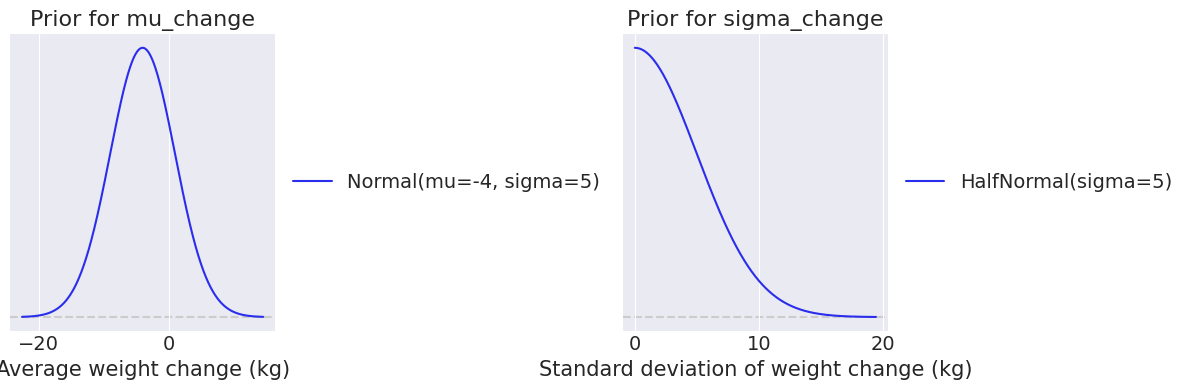

In [ ]:
# Weight is measured in kilograms.
# These priors are chosen in kilograms.

change_prior_mean = -4
change_prior_sigma = 5
change_sigma_prior = 5

mu_prior = pz.Normal(
    mu=change_prior_mean,
    sigma=change_prior_sigma
)

sigma_prior = pz.HalfNormal(
    sigma=change_sigma_prior
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mu_prior.plot_pdf(ax=axes[0])
axes[0].set_title("Prior for mu_change")
axes[0].set_xlabel("Average weight change (kg)")

sigma_prior.plot_pdf(ax=axes[1])
axes[1].set_title("Prior for sigma_change")
axes[1].set_xlabel("Standard deviation of weight change (kg)")

plt.tight_layout()
plt.show()

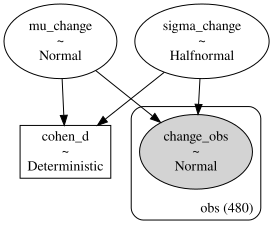

In [ ]:
coords_food_change = {"obs": np.arange(len(change))}

with pm.Model(coords=coords_food_change) as paired_normal_model:
    # Priors
    mu_change = pm.Normal("mu_change", mu=change_prior_mean, sigma=change_prior_sigma)
    sigma_change = pm.HalfNormal("sigma_change", sigma=change_sigma_prior)
    # effect size (Deterministic)
    cohen_d = pm.Deterministic("cohen_d", mu_change / sigma_change)
    # Likelihood
    change_obs = pm.Normal("change_obs", mu=mu_change, sigma=sigma_change, observed=change, dims="obs")

pm.model_to_graphviz(paired_normal_model)

### Prior predictive check

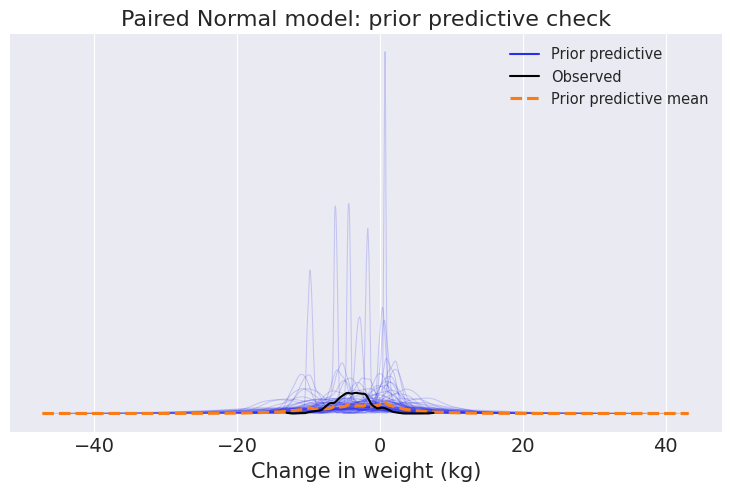

In [ ]:
with paired_normal_model:
    idata_paired_normal_prior = pm.sample_prior_predictive(
        samples=1000,
        random_seed=random_seed
    )

az.plot_ppc(
    idata_paired_normal_prior,
    group="prior",
    observed=True,
    num_pp_samples=100,
    random_seed=random_seed
)

plt.title("Paired Normal model: prior predictive check")
plt.xlabel("Change in weight (kg)")
plt.show()

### Sample posterior

In [ ]:
with paired_normal_model:
    idata_paired_normal = pm.sample(
        draws=1000,
        chains=4,
        random_seed=random_seed
    )

idata_paired_normal.extend(idata_paired_normal_prior)

idata_paired_normal

Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

### Diagnostics

In [ ]:
az.summary(
    idata_paired_normal,
    var_names=["mu_change", "sigma_change", "cohen_d"],
    kind="diagnostics"
)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_change,0.002,0.002,3905.0,2987.0,1.0
sigma_change,0.001,0.001,4262.0,2942.0,1.0
cohen_d,0.001,0.001,4119.0,3154.0,1.0


/tmp/ipykernel_2651/1376568512.py:13: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.8)


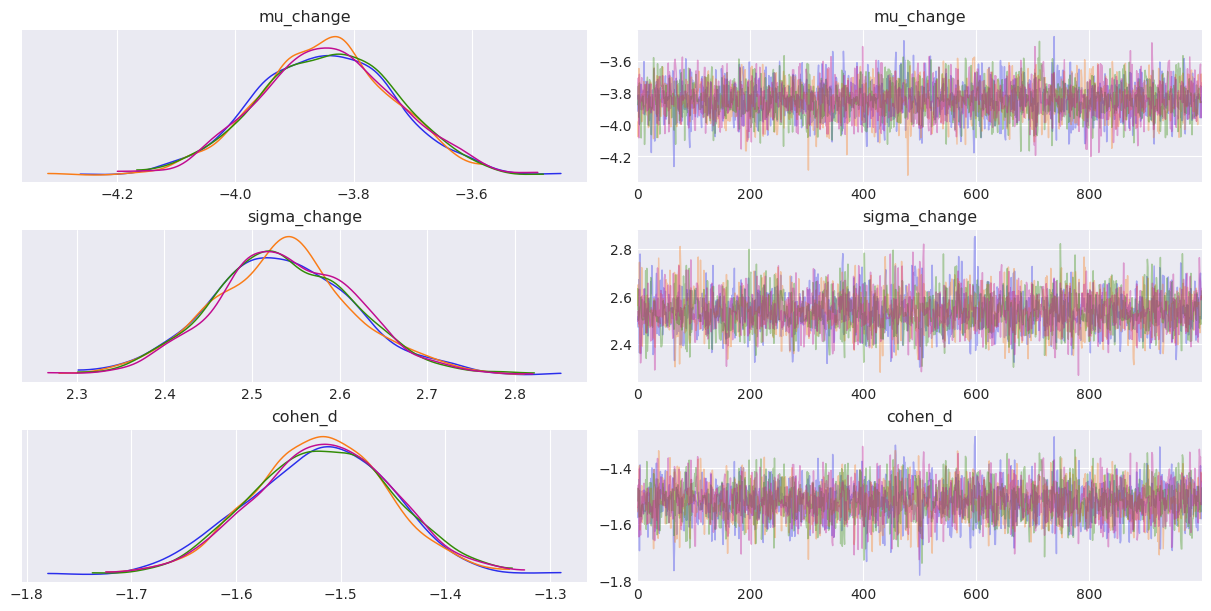

Number of divergences: 0


In [ ]:
az.plot_trace(
    idata_paired_normal,
    var_names=["mu_change", "sigma_change", "cohen_d"],
    compact=False
)

plt.subplots_adjust(hspace=0.8)
plt.show()

paired_normal_divergences = idata_paired_normal.sample_stats["diverging"].sum().values
print(f"Number of divergences: {paired_normal_divergences}")

### Posterior and Bayesian hypothesis testing

In [ ]:
az.summary(
    idata_paired_normal,
    var_names=["mu_change", "sigma_change", "cohen_d"],
    kind="stats",
    hdi_prob=HDI_MASS
).round(2)

,mean,sd,hdi_3%,hdi_97%
mu_change,-3.85,0.11,-4.06,-3.64
sigma_change,2.54,0.08,2.38,2.69
cohen_d,-1.52,0.07,-1.65,-1.40


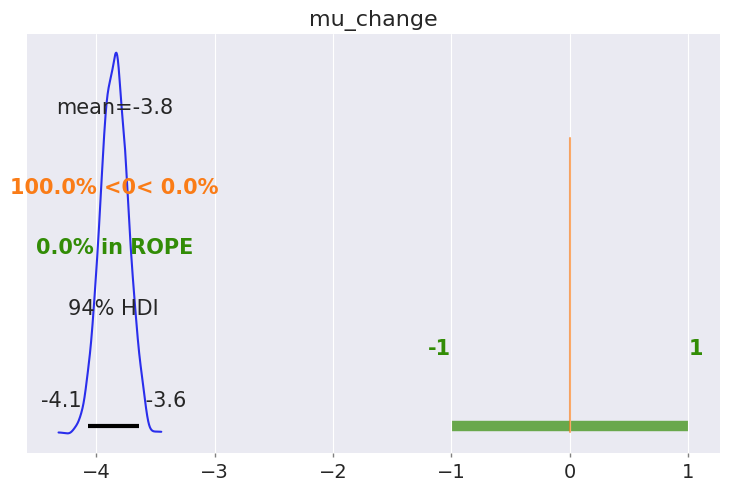

,quantity,posterior mean,posterior median,94% HDI low,94% HDI high,Pr(value > 0),Pr(value < 0),Pr(value in ROPE)
0,Mean change after - before,-3.847,-3.845,-4.064,-3.637,0.000,1.000,0.000
1,Cohen's d for paired change,-1.518,-1.517,-1.648,-1.398,0.000,1.000,nan


In [ ]:


# ROPE for mean weight change.
# Here, changes smaller than 1 kg in either direction are treated as practically negligible.
# This is a teaching choice and should be justified by domain knowledge in real analysis.

rope_change = (-1, 1)

az.plot_posterior(
    idata_paired_normal,
    var_names=["mu_change"],
    ref_val=0, rope=rope_change)

plt.show()

mu_change_samples = idata_paired_normal.posterior["mu_change"].values.ravel()
cohen_d_change_samples = idata_paired_normal.posterior["cohen_d"].values.ravel()

mu_change_summary = summarize_hdi(mu_change_samples)
cohen_d_change_summary = summarize_hdi(cohen_d_change_samples)

prob_change_positive = np.mean(mu_change_samples > 0)
prob_change_negative = np.mean(mu_change_samples < 0)
prob_change_in_rope = np.mean(
    (mu_change_samples >= rope_change[0])
    & (mu_change_samples <= rope_change[1])
)

paired_bayesian_summary = pd.DataFrame([
    {
        "quantity": "Mean change after - before",
        "posterior mean": mu_change_summary["mean"],
        "posterior median": mu_change_summary["median"],
        f"{HDI_MASS:.0%} HDI low": mu_change_summary["hdi_low"],
        f"{HDI_MASS:.0%} HDI high": mu_change_summary["hdi_high"],
        "Pr(value > 0)": prob_change_positive,
        "Pr(value < 0)": prob_change_negative,
        "Pr(value in ROPE)": prob_change_in_rope,
    },
    {
        "quantity": "Cohen's d for paired change",
        "posterior mean": cohen_d_change_summary["mean"],
        "posterior median": cohen_d_change_summary["median"],
        f"{HDI_MASS:.0%} HDI low": cohen_d_change_summary["hdi_low"],
        f"{HDI_MASS:.0%} HDI high": cohen_d_change_summary["hdi_high"],
        "Pr(value > 0)": np.mean(cohen_d_change_samples > 0),
        "Pr(value < 0)": np.mean(cohen_d_change_samples < 0),
        "Pr(value in ROPE)": np.nan,
    }
])

paired_bayesian_summary.style.format({
    "posterior mean": "{:.3f}",
    "posterior median": "{:.3f}",
    f"{HDI_MASS:.0%} HDI low": "{:.3f}",
    f"{HDI_MASS:.0%} HDI high": "{:.3f}",
    "Pr(value > 0)": "{:.3f}",
    "Pr(value < 0)": "{:.3f}",
    "Pr(value in ROPE)": "{:.3f}",
})

### Posterior predictive check

Output()

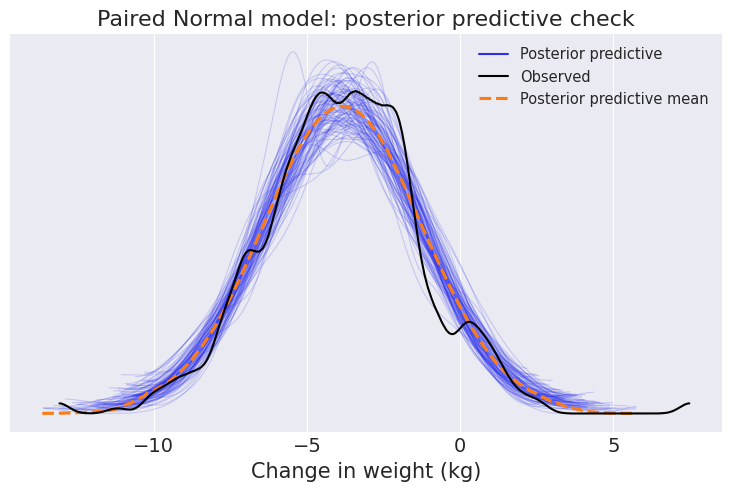

In [ ]:
with paired_normal_model:
    idata_paired_normal = pm.sample_posterior_predictive(
        idata_paired_normal,
        var_names=["change_obs"],
        random_seed=random_seed,
        extend_inferencedata=True
    )

az.plot_ppc(
    idata_paired_normal,
    group="posterior",
    observed=True,
    num_pp_samples=100,
    random_seed=random_seed
)

plt.title("Paired Normal model: posterior predictive check")
plt.xlabel("Change in weight (kg)")
plt.show()

## Frequentist paired tests

In [ ]:
paired_t_result = stats.ttest_rel(after, before)
wilcoxon_result = stats.wilcoxon(change, zero_method="wilcox")

mean_change = change.mean()
sd_change = change.std(ddof=1)
n_change = len(change)
se_change = sd_change / np.sqrt(n_change)

t_critical_change = stats.t.ppf(1 - SIGNIFICANCE_ALPHA / 2, df=n_change - 1)
ci_change_low = mean_change - t_critical_change * se_change
ci_change_high = mean_change + t_critical_change * se_change

cohens_d_paired = mean_change / sd_change

paired_frequentist_summary = pd.DataFrame([
    {
        "test": "Paired t-test",
        "statistic": paired_t_result.statistic,
        "p-value": paired_t_result.pvalue,
        "mean change": mean_change,
        "CI low": ci_change_low,
        "CI high": ci_change_high,
        "Cohen's d": cohens_d_paired,
    },
    {
        "test": "Wilcoxon signed-rank test",
        "statistic": wilcoxon_result.statistic,
        "p-value": wilcoxon_result.pvalue,
        "mean change": np.nan,
        "CI low": np.nan,
        "CI high": np.nan,
        "Cohen's d": np.nan,
    }
])

paired_frequentist_summary.style.format({
    "statistic": "{:.3f}",
    "p-value": "{:.4g}",
    "mean change": "{:.3f}",
    "CI low": "{:.3f}",
    "CI high": "{:.3f}",
    "Cohen's d": "{:.3f}",
})

,test,statistic,p-value,mean change,CI low,CI high,Cohen's d
0,Paired t-test,-33.319,7.976e-127,-3.851,-4.078,-3.624,-1.521
1,Wilcoxon signed-rank test,1713.000,6.581e-75,nan,nan,nan,nan


### Plot the paired t-test reference distribution

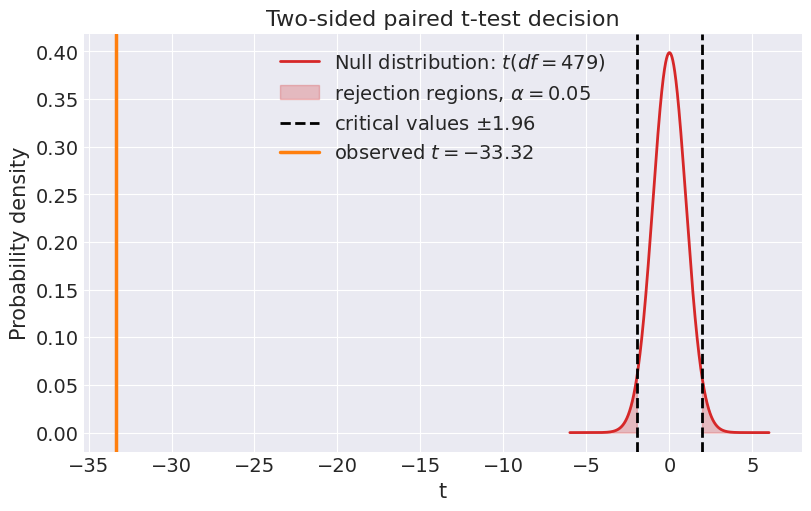

In [ ]:
t_observed = paired_t_result.statistic
df_paired = n_change - 1

t_x = np.linspace(-6, 6, 2000)
t_pdf = stats.t.pdf(t_x, df=df_paired)
t_critical = stats.t.ppf(1 - SIGNIFICANCE_ALPHA / 2, df=df_paired)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    t_x,
    t_pdf,
    color=FREQUENTIST_COLOR,
    linewidth=2,
    label=rf"Null distribution: $t(df={df_paired})$"
)

left_rejection = t_x <= -t_critical
right_rejection = t_x >= t_critical

ax.fill_between(
    t_x[left_rejection],
    0,
    t_pdf[left_rejection],
    color=FREQUENTIST_COLOR,
    alpha=0.25,
    label=rf"rejection regions, $\alpha={SIGNIFICANCE_ALPHA}$"
)

ax.fill_between(
    t_x[right_rejection],
    0,
    t_pdf[right_rejection],
    color=FREQUENTIST_COLOR,
    alpha=0.25
)

ax.axvline(-t_critical, color="black", linestyle="--", linewidth=2)
ax.axvline(t_critical, color="black", linestyle="--", linewidth=2, label=rf"critical values $\pm {t_critical:.2f}$")
ax.axvline(t_observed, color="tab:orange", linewidth=2.5, label=rf"observed $t={t_observed:.2f}$")

ax.set_xlabel("t")
ax.set_ylabel("Probability density")
ax.set_title("Two-sided paired t-test decision")
ax.legend()
plt.show()

### Reporting template

In [ ]:
paired_decision = "reject H0" if paired_t_result.pvalue < SIGNIFICANCE_ALPHA else "fail to reject H0"

print(f"""
Paired weight analysis

The observed mean change after six weeks was {mean_change:.2f} kg
(after - before), with a {(1 - SIGNIFICANCE_ALPHA):.0%} confidence interval
from {ci_change_low:.2f} to {ci_change_high:.2f} kg.

The Bayesian paired Normal model estimated the posterior mean change as
{mu_change_summary['mean']:.2f} kg, with a {HDI_MASS:.0%} HDI from
{mu_change_summary['hdi_low']:.2f} to {mu_change_summary['hdi_high']:.2f} kg.
The posterior probability that the change is positive was {prob_change_positive:.3f}.

The frequentist paired t-test gave t({df_paired}) = {paired_t_result.statistic:.2f}
and p = {paired_t_result.pvalue:.4g}. Therefore, using alpha = {SIGNIFICANCE_ALPHA:.2f},
we {paired_decision}.
""")


Paired weight analysis

The observed mean change after six weeks was -3.85 kg
(after - before), with a 95% confidence interval
from -4.08 to -3.62 kg.

The Bayesian paired Normal model estimated the posterior mean change as
-3.85 kg, with a 94% HDI from
-4.06 to -3.64 kg.
The posterior probability that the change is positive was 0.000.

The frequentist paired t-test gave t(479) = -33.32
and p = 7.976e-127. Therefore, using alpha = 0.05,
we reject H0.



# Robust model: Student-t likelihood

A Normal likelihood may have trouble with heavy tails or outliers.
A Student-t likelihood is similar to a Normal likelihood but has thicker tails.

\[
\text{change}_i \sim \text{StudentT}(\nu, \mu_{\text{change}}, \sigma_{\text{change}})
\]

The parameter \(\nu\) controls tail thickness:

- smaller \(\nu\): heavier tails
- larger \(\nu\): closer to Normal

### Normal versus Student-t distributions

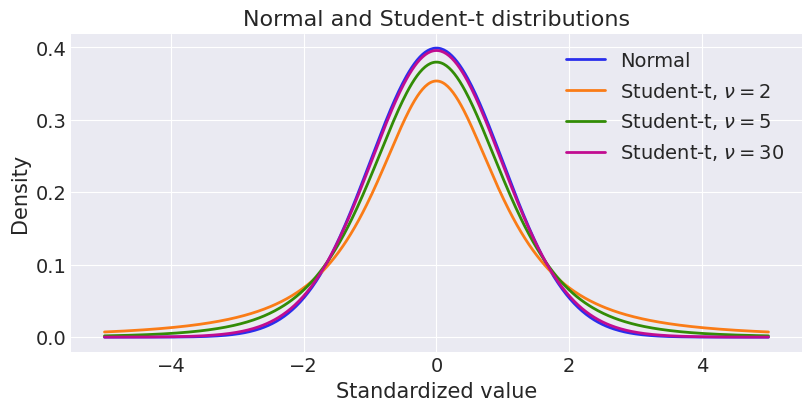

In [ ]:
x = np.linspace(-5, 5, 500)

plt.figure(figsize=(8, 4))

plt.plot(x, stats.norm.pdf(x), linewidth=2, label="Normal")

for nu_value in [2, 5, 30]:
    plt.plot(
        x,
        stats.t.pdf(x, df=nu_value),
        linewidth=2,
        label=rf"Student-t, $\nu={nu_value}$"
    )

plt.xlabel("Standardized value")
plt.ylabel("Density")
plt.title("Normal and Student-t distributions")
plt.legend()
plt.show()

## Model 3: Robust paired Student-t model

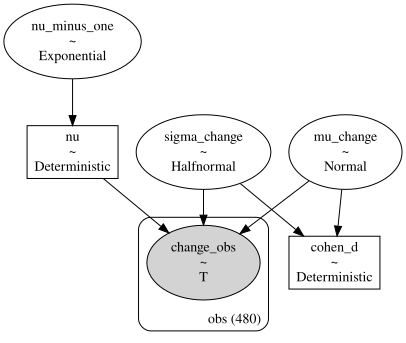

In [ ]:
with pm.Model(coords=coords_food_change) as paired_student_t_model:
    # Priors
    mu_change = pm.Normal("mu_change", mu=change_prior_mean, sigma=change_prior_sigma)
    sigma_change = pm.HalfNormal("sigma_change", sigma=change_sigma_prior)
    # We use nu_minus_one + 1 so nu is always larger than 1.
    nu_minus_one = pm.Exponential("nu_minus_one", lam=1 / 30)
    nu = pm.Deterministic("nu", nu_minus_one + 1)

    # Effect size
    cohen_d = pm.Deterministic( "cohen_d", mu_change / sigma_change )

    # Likelihood
    change_obs = pm.StudentT("change_obs",nu=nu, mu=mu_change, sigma=sigma_change,
        observed=change, dims="obs")

pm.model_to_graphviz(paired_student_t_model)

### Prior predictive check

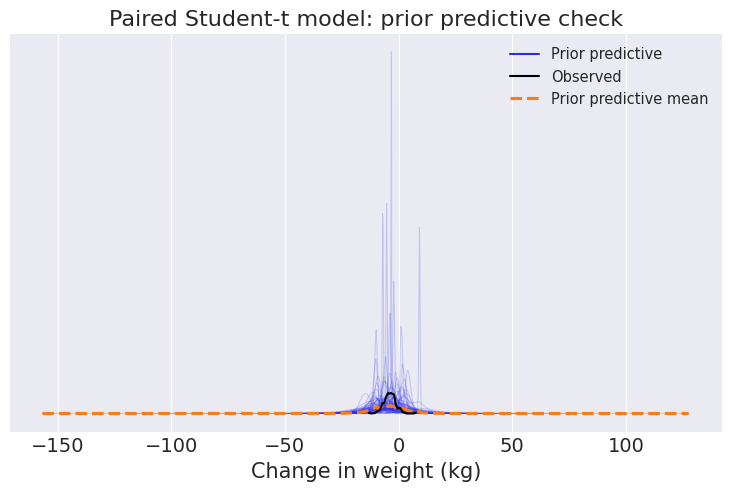

In [ ]:
with paired_student_t_model:
    idata_paired_student_t_prior = pm.sample_prior_predictive(
        samples=1000,
        random_seed=random_seed
    )

az.plot_ppc(
    idata_paired_student_t_prior,
    group="prior",
    observed=True,
    num_pp_samples=100,
    random_seed=random_seed
)

plt.title("Paired Student-t model: prior predictive check")
plt.xlabel("Change in weight (kg)")
plt.show()

### Sample posterior

In [ ]:
with paired_student_t_model:
    idata_paired_student_t = pm.sample(
        draws=1000,
        chains=4,
        target_accept=0.9,
        random_seed=random_seed
    )

idata_paired_student_t.extend(idata_paired_student_t_prior)

idata_paired_student_t

Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

### Diagnostics

In [ ]:
az.summary(
    idata_paired_student_t,
    var_names=["mu_change", "sigma_change", "nu", "cohen_d"],
    kind="diagnostics"
)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_change,0.002,0.002,2539.0,2570.0,1.0
sigma_change,0.002,0.002,2226.0,2233.0,1.0
nu,0.445,0.705,2293.0,2376.0,1.0
cohen_d,0.002,0.001,2456.0,2355.0,1.0


/tmp/ipykernel_2651/4999875.py:13: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.9)


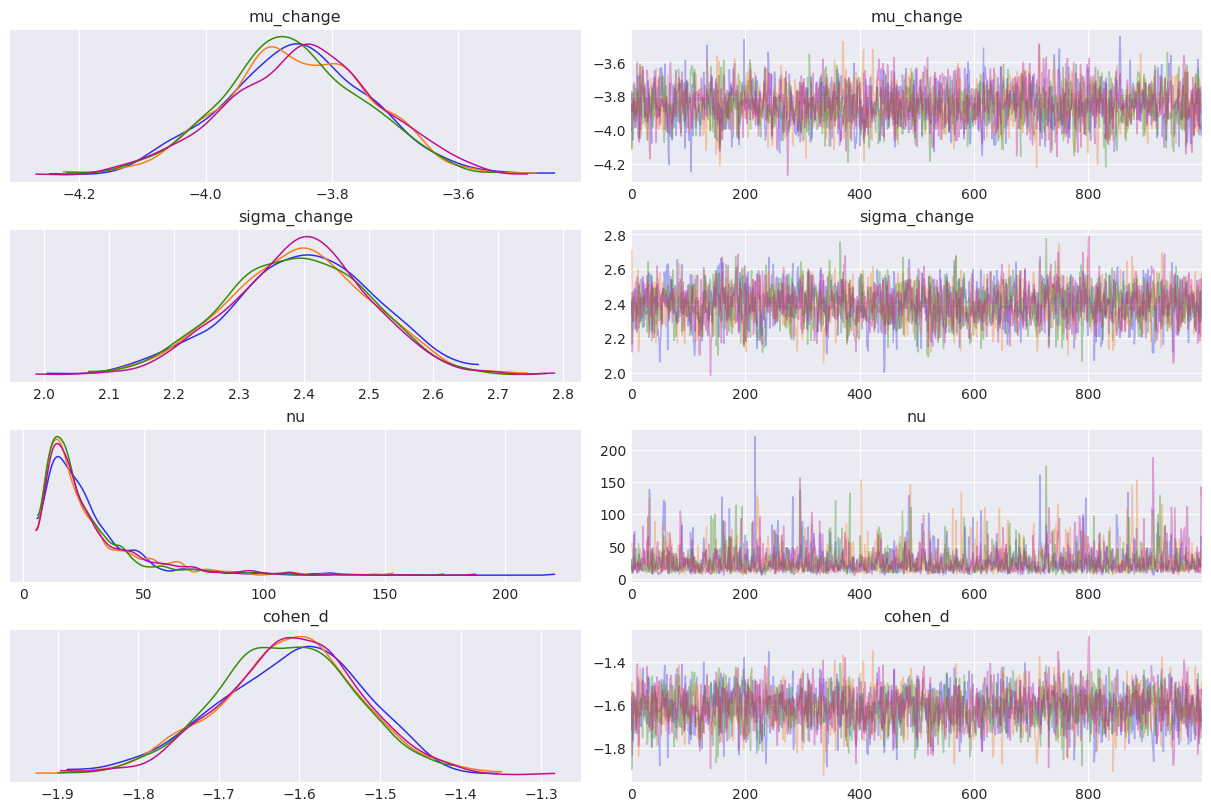

Number of divergences: 0


In [ ]:
az.plot_trace(
    idata_paired_student_t,
    var_names=["mu_change", "sigma_change", "nu", "cohen_d"],
    compact=False
)

plt.subplots_adjust(hspace=0.9)
plt.show()

paired_student_t_divergences = idata_paired_student_t.sample_stats["diverging"].sum().values
print(f"Number of divergences: {paired_student_t_divergences}")

### Posterior predictive check

Output()

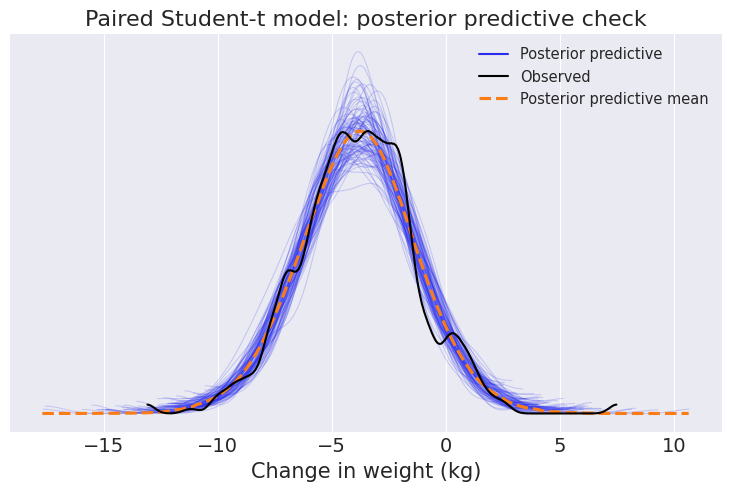

In [ ]:
with paired_student_t_model:
    idata_paired_student_t = pm.sample_posterior_predictive(
        idata_paired_student_t,
        var_names=["change_obs"],
        random_seed=random_seed,
        extend_inferencedata=True
    )

az.plot_ppc(
    idata_paired_student_t,
    group="posterior",
    observed=True,
    num_pp_samples=100,
    random_seed=random_seed
)

plt.title("Paired Student-t model: posterior predictive check")
plt.xlabel("Change in weight (kg)")
plt.show()

### Compare Normal and Student-t posteriors

In [ ]:
paired_normal_posterior = az.extract(
    idata_paired_normal,
    var_names=["mu_change", "sigma_change", "cohen_d"]
)

paired_student_t_posterior = az.extract(
    idata_paired_student_t,
    var_names=["mu_change", "sigma_change", "nu", "cohen_d"]
)

comparison_posterior_table = pd.DataFrame([
    {
        "model": "Normal",
        "quantity": "mu_change",
        "posterior mean": paired_normal_posterior["mu_change"].values.mean(),
        "HDI low": az.hdi(paired_normal_posterior["mu_change"].values, hdi_prob=HDI_MASS)[0],
        "HDI high": az.hdi(paired_normal_posterior["mu_change"].values, hdi_prob=HDI_MASS)[1],
    },
    {
        "model": "Student-t",
        "quantity": "mu_change",
        "posterior mean": paired_student_t_posterior["mu_change"].values.mean(),
        "HDI low": az.hdi(paired_student_t_posterior["mu_change"].values, hdi_prob=HDI_MASS)[0],
        "HDI high": az.hdi(paired_student_t_posterior["mu_change"].values, hdi_prob=HDI_MASS)[1],
    },
    {
        "model": "Normal",
        "quantity": "sigma_change",
        "posterior mean": paired_normal_posterior["sigma_change"].values.mean(),
        "HDI low": az.hdi(paired_normal_posterior["sigma_change"].values, hdi_prob=HDI_MASS)[0],
        "HDI high": az.hdi(paired_normal_posterior["sigma_change"].values, hdi_prob=HDI_MASS)[1],
    },
    {
        "model": "Student-t",
        "quantity": "sigma_change",
        "posterior mean": paired_student_t_posterior["sigma_change"].values.mean(),
        "HDI low": az.hdi(paired_student_t_posterior["sigma_change"].values, hdi_prob=HDI_MASS)[0],
        "HDI high": az.hdi(paired_student_t_posterior["sigma_change"].values, hdi_prob=HDI_MASS)[1],
    },
    {
        "model": "Student-t",
        "quantity": "nu",
        "posterior mean": paired_student_t_posterior["nu"].values.mean(),
        "HDI low": az.hdi(paired_student_t_posterior["nu"].values, hdi_prob=HDI_MASS)[0],
        "HDI high": az.hdi(paired_student_t_posterior["nu"].values, hdi_prob=HDI_MASS)[1],
    },
])

comparison_posterior_table.style.format({
    "posterior mean": "{:.3f}",
    "HDI low": "{:.3f}",
    "HDI high": "{:.3f}",
})

,model,quantity,posterior mean,HDI low,HDI high
0,Normal,mu_change,-3.847,-4.064,-3.637
1,Student-t,mu_change,-3.855,-4.067,-3.637
2,Normal,sigma_change,2.536,2.385,2.693
3,Student-t,sigma_change,2.394,2.185,2.589
4,Student-t,nu,26.916,5.865,64.971


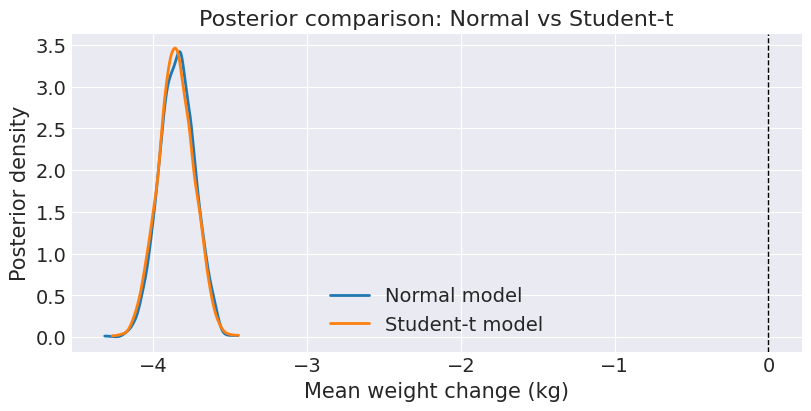

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

az.plot_kde(
    paired_normal_posterior["mu_change"].values,
    ax=ax,
    plot_kwargs={"linewidth": 2, "color": BAYESIAN_COLOR},
    label="Normal model"
)

az.plot_kde(
    paired_student_t_posterior["mu_change"].values,
    ax=ax,
    plot_kwargs={"linewidth": 2, "color": MODEL_COMPARISON_COLOR},
    label="Student-t model"
)

ax.axvline(0, color=NULL_COLOR, linestyle="--", linewidth=1)
ax.set_xlabel("Mean weight change (kg)")
ax.set_ylabel("Posterior density")
ax.set_title("Posterior comparison: Normal vs Student-t")
ax.legend()
plt.show()

# Data 2: Food diet pre-weight by gender

The same food diet dataset is used for the independent group comparison.

We will compare pre-diet weight between male and female participants.
This is an unpaired comparison because different people belong to each group.

In [ ]:
food_group = food_df.dropna(subset=["pre.weight", "gender_label"]).copy()
food_group["gender_label"] = food_group["gender_label"].astype(str).str.lower().str.strip()
food_group = food_group[food_group["gender_label"].isin(["female", "male"])].copy()

# Keep the order explicit so that delta = male - female is easy to interpret.
gender_categories = np.array(["female", "male"])
food_group["gender_label"] = pd.Categorical(
    food_group["gender_label"],
    categories=gender_categories,
    ordered=True
)

gender_idx = food_group["gender_label"].cat.codes.to_numpy()
pre_weight = food_group["pre.weight"].to_numpy()
gender_labels = food_group["gender_label"].astype(str).to_numpy()

food_group[["Person", "gender_label", "Age", "Height", "Diet", "pre.weight", "weight6weeks"]].head()

,Person,gender_label,Age,Height,Diet,pre.weight,weight6weeks
0,1,female,22,159,1,58.0,54.2
1,2,female,46,192,1,60.0,54.0
2,3,female,55,170,1,64.0,63.3
3,4,female,33,171,1,64.0,61.1
4,5,female,50,170,1,65.0,62.2


### Plot pre-diet weight by gender

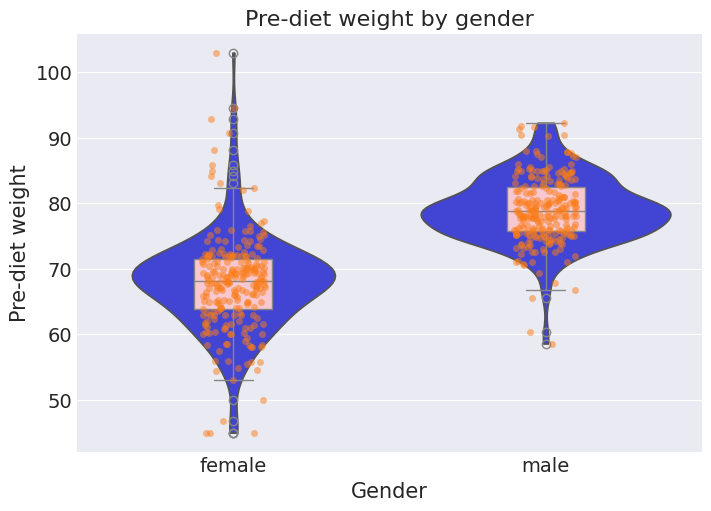

/tmp/ipykernel_2651/355396781.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  food_group.groupby("gender_label")["pre.weight"].describe()


,count,mean,std,min,25%,50%,75%,max
gender_label,,,,,,,,
female,240.0,67.829167,7.548486,45.0,63.875,68.1,71.50,103.0
male,240.0,79.025833,5.061835,58.6,75.800,78.8,82.45,92.3


In [ ]:
plt.figure(figsize=(7, 5))

sns.violinplot(
    data=food_group,
    x="gender_label",
    y="pre.weight",
    inner=None,
    cut=0
)

sns.boxplot(
    data=food_group,
    x="gender_label",
    y="pre.weight",
    width=0.25,
    color="pink"
)

sns.stripplot(
    data=food_group,
    x="gender_label",
    y="pre.weight",
    alpha=0.5,
    jitter=True
)

plt.xlabel("Gender")
plt.ylabel("Pre-diet weight")
plt.title("Pre-diet weight by gender")
plt.show()

food_group.groupby("gender_label")["pre.weight"].describe()

# Unpaired group-difference model

For independent groups, we can give each group its own mean.

\[
\mu_g \sim \text{Normal}(72, 15)
\]

\[
\sigma \sim \text{HalfNormal}(12)
\]

\[
y_i \sim \text{Normal}(\mu_{\text{group}[i]}, \sigma)
\]

The raw effect is:

\[
\Delta_\mu = \mu_{male} - \mu_{female}
\]

The standardized effect is:

\[
d = \frac{\Delta_\mu}{\sigma}
\]

## Model 4: Bayesian group model with shared sigma

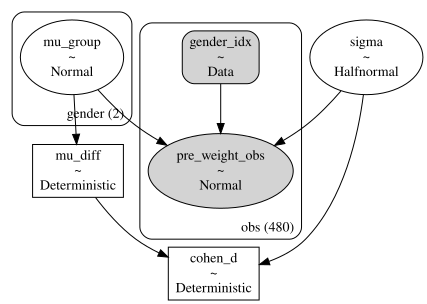

In [ ]:
coords_food_gender = {
    "gender": gender_categories,
    "obs": np.arange(len(pre_weight))}

with pm.Model(coords=coords_food_gender) as food_gender_shared_sigma_model:
    # Data
    gender = pm.Data("gender_idx", gender_idx, dims="obs")
    # Prior
    mu_group = pm.Normal("mu_group", mu=72.0, sigma=15.0, dims="gender")
    sigma = pm.HalfNormal("sigma", sigma=12.0)

    # Raw effect size
    mu_diff = pm.Deterministic( "mu_diff",mu_group[1] - mu_group[0])

    # Normalized effect size
    cohen_d = pm.Deterministic("cohen_d", mu_diff / sigma)

    # Likelihood
    pre_weight_obs = pm.Normal("pre_weight_obs", mu=mu_group[gender], sigma=sigma,
        observed=pre_weight, dims="obs")

pm.model_to_graphviz(food_gender_shared_sigma_model)

### Prior predictive check

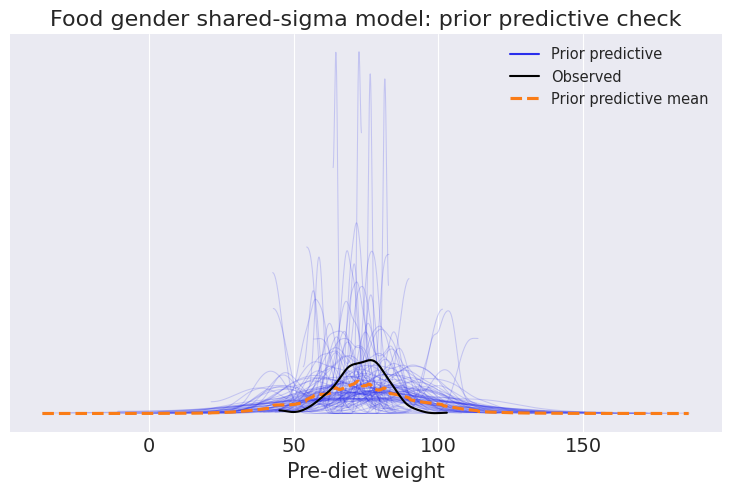

In [ ]:
with food_gender_shared_sigma_model:
    idata_food_gender_shared_prior = pm.sample_prior_predictive(
        samples=1000,
        random_seed=random_seed)

az.plot_ppc(
    idata_food_gender_shared_prior,
    group="prior",
    observed=True,
    num_pp_samples=100,
    random_seed=random_seed)

plt.title("Food gender shared-sigma model: prior predictive check")
plt.xlabel("Pre-diet weight")
plt.show()

### Sample posterior

In [ ]:
with food_gender_shared_sigma_model:
    idata_food_gender_shared = pm.sample(
        draws=1000,
        chains=4,
        random_seed=random_seed
    )

idata_food_gender_shared.extend(idata_food_gender_shared_prior)

idata_food_gender_shared

Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data

### Diagnostics

In [ ]:
az.summary(
    idata_food_gender_shared,
    var_names=["mu_group", "sigma", "mu_diff", "cohen_d"],
    kind="diagnostics"
)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_group[female],0.005,0.006,6888.0,2939.0,1.0
mu_group[male],0.005,0.006,5920.0,3265.0,1.0
sigma,0.003,0.003,6542.0,3221.0,1.0
mu_diff,0.008,0.009,6051.0,3248.0,1.0
cohen_d,0.001,0.002,6170.0,3292.0,1.0


/tmp/ipykernel_2651/1308300833.py:7: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.9)


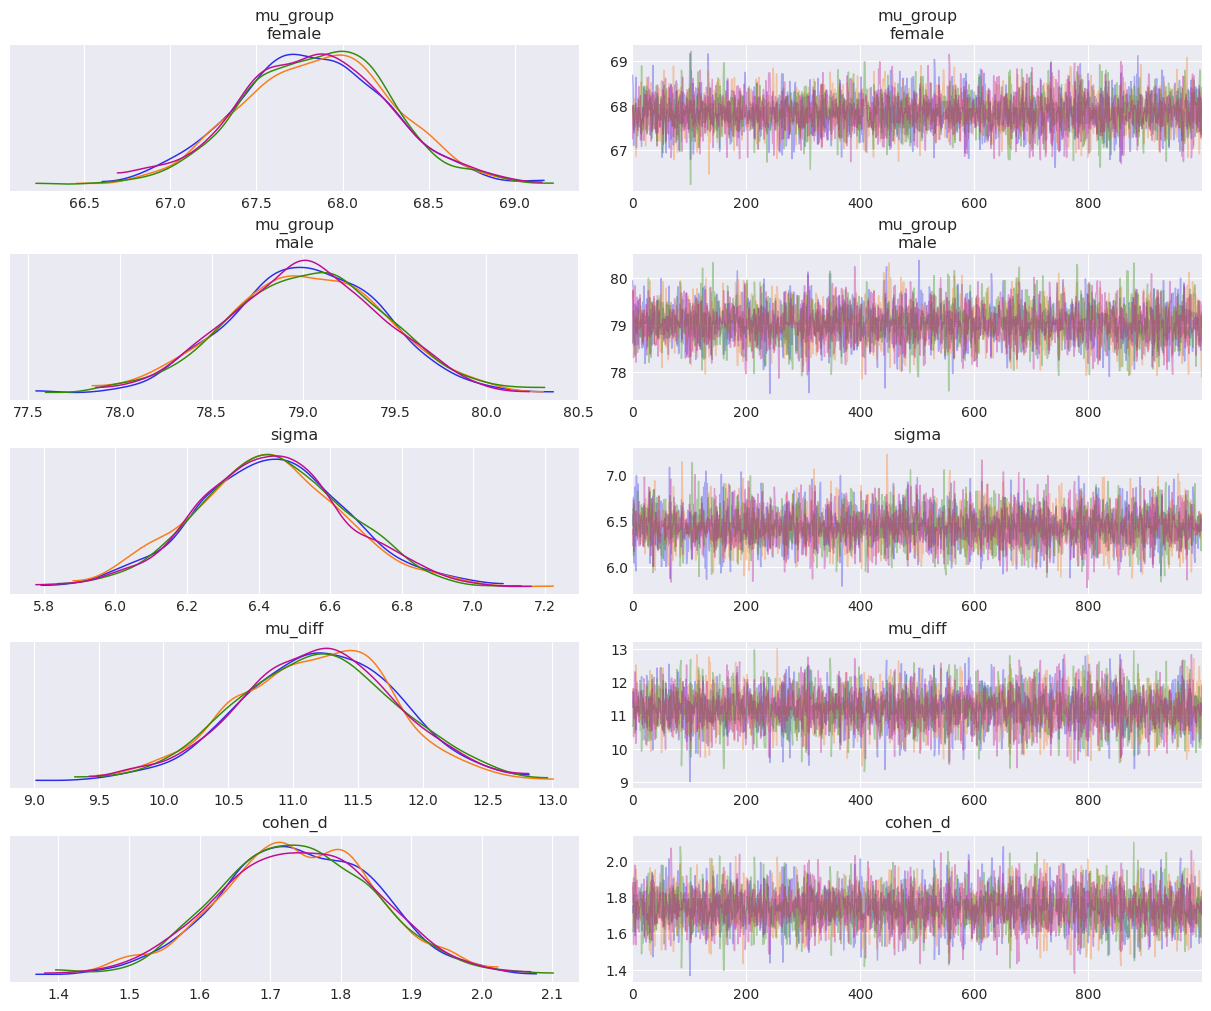

Number of divergences: 0


In [ ]:
az.plot_trace(
    idata_food_gender_shared,
    var_names=["mu_group", "sigma", "mu_diff", "cohen_d"],
    compact=False
)

plt.subplots_adjust(hspace=0.9)
plt.show()

food_gender_shared_divergences = idata_food_gender_shared.sample_stats["diverging"].sum().values
print(f"Number of divergences: {food_gender_shared_divergences}")

### Posterior predictive check

Output()

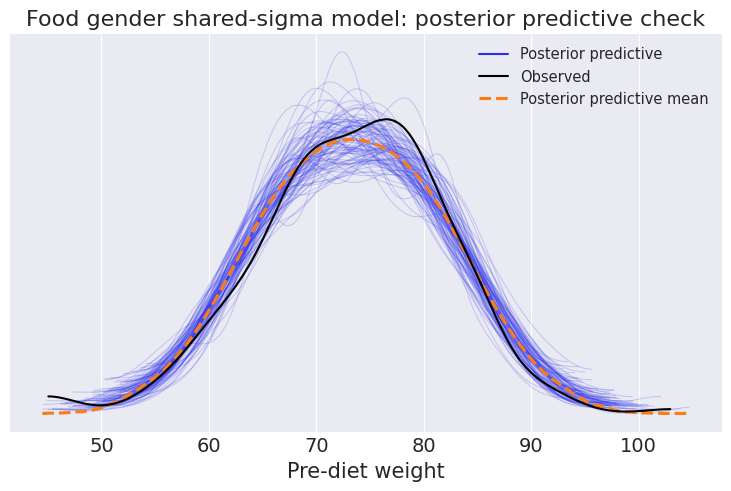

In [ ]:
with food_gender_shared_sigma_model:
    idata_food_gender_shared = pm.sample_posterior_predictive(
        idata_food_gender_shared,
        var_names=["pre_weight_obs"],
        random_seed=random_seed,
        extend_inferencedata=True
    )

az.plot_ppc(
    idata_food_gender_shared,
    group="posterior",
    observed=True,
    num_pp_samples=100,
    random_seed=random_seed
)

plt.title("Food gender shared-sigma model: posterior predictive check")
plt.xlabel("Pre-diet weight")
plt.show()

### Posterior effect sizes

In [ ]:
az.summary(
    idata_food_gender_shared,
    var_names=["mu_group", "sigma", "mu_diff", "cohen_d"],
    kind="stats",
    hdi_prob=HDI_MASS
).round(3)

,mean,sd,hdi_3%,hdi_97%
mu_group[female],67.839,0.422,67.031,68.629
mu_group[male],79.021,0.419,78.222,79.783
sigma,6.436,0.208,6.001,6.796
mu_diff,11.182,0.604,10.097,12.392
cohen_d,1.739,0.109,1.538,1.947


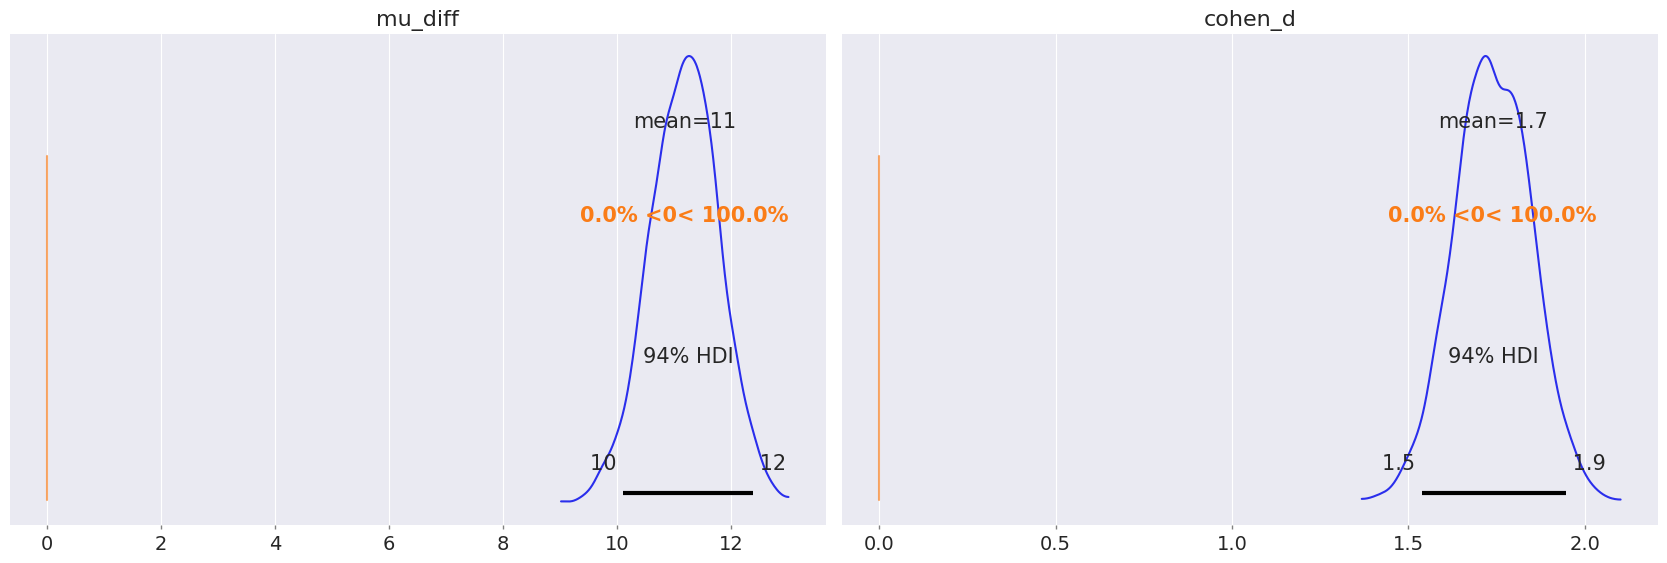

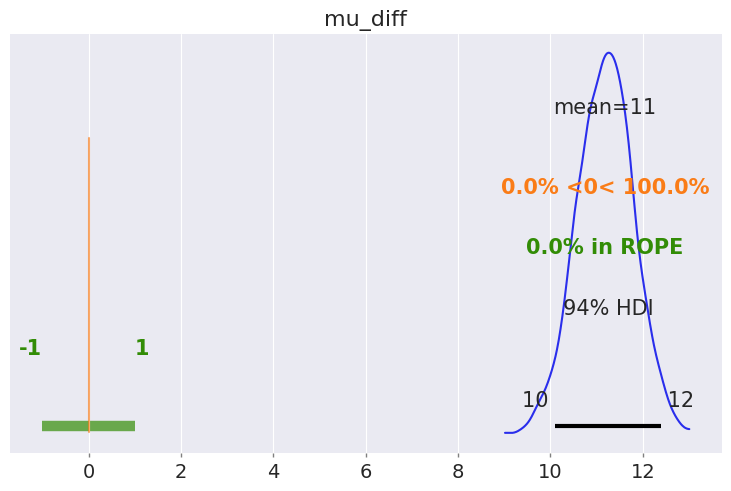

,quantity,posterior mean,posterior median,94% HDI low,94% HDI high,Pr(value > 0),Pr(value < 0),Pr(value in ROPE)
0,Male - female pre-diet weight,11.182,11.194,10.097,12.392,1.000,0.000,0.000
1,Cohen's d,1.739,1.738,1.538,1.947,1.000,0.000,nan


In [ ]:
# ROPE for pre-weight difference.
# Here, differences smaller than 1 kg in either direction are treated as practically negligible.
# This is a teaching choice and should be justified by domain knowledge in real analysis.


az.plot_posterior(
    idata_food_gender_shared,
    var_names=["mu_diff", "cohen_d"],
    ref_val=0,
    hdi_prob=HDI_MASS
)

plt.show()

rope_pre_weight = (-1, 1)

az.plot_posterior(
    idata_food_gender_shared,
    var_names=["mu_diff"],
    ref_val=0,
    rope=rope_pre_weight,
    hdi_prob=HDI_MASS
)

plt.show()

mu_diff_samples = idata_food_gender_shared.posterior["mu_diff"].values.ravel()
cohen_d_group_samples = idata_food_gender_shared.posterior["cohen_d"].values.ravel()

mu_diff_summary = summarize_hdi(mu_diff_samples)
cohen_d_group_summary = summarize_hdi(cohen_d_group_samples)

prob_mu_diff_positive = np.mean(mu_diff_samples > 0)
prob_mu_diff_negative = np.mean(mu_diff_samples < 0)
prob_mu_diff_in_rope = np.mean(
    (mu_diff_samples >= rope_pre_weight[0])
    & (mu_diff_samples <= rope_pre_weight[1])
)

group_bayesian_summary = pd.DataFrame([
    {
        "quantity": "Male - female pre-diet weight",
        "posterior mean": mu_diff_summary["mean"],
        "posterior median": mu_diff_summary["median"],
        f"{HDI_MASS:.0%} HDI low": mu_diff_summary["hdi_low"],
        f"{HDI_MASS:.0%} HDI high": mu_diff_summary["hdi_high"],
        "Pr(value > 0)": prob_mu_diff_positive,
        "Pr(value < 0)": prob_mu_diff_negative,
        "Pr(value in ROPE)": prob_mu_diff_in_rope,
    },
    {
        "quantity": "Cohen's d",
        "posterior mean": cohen_d_group_summary["mean"],
        "posterior median": cohen_d_group_summary["median"],
        f"{HDI_MASS:.0%} HDI low": cohen_d_group_summary["hdi_low"],
        f"{HDI_MASS:.0%} HDI high": cohen_d_group_summary["hdi_high"],
        "Pr(value > 0)": np.mean(cohen_d_group_samples > 0),
        "Pr(value < 0)": np.mean(cohen_d_group_samples < 0),
        "Pr(value in ROPE)": np.nan,
    }
])

group_bayesian_summary.style.format({
    "posterior mean": "{:.3f}",
    "posterior median": "{:.3f}",
    f"{HDI_MASS:.0%} HDI low": "{:.3f}",
    f"{HDI_MASS:.0%} HDI high": "{:.3f}",
    "Pr(value > 0)": "{:.3f}",
    "Pr(value < 0)": "{:.3f}",
    "Pr(value in ROPE)": "{:.3f}",
})

## Frequentist independent group tests

In [ ]:
female_weight = food_group.loc[food_group["gender_label"] == "female", "pre.weight"].to_numpy()
male_weight = food_group.loc[food_group["gender_label"] == "male", "pre.weight"].to_numpy()

pooled_t_result = stats.ttest_ind(
    male_weight,
    female_weight,
    equal_var=True
)

welch_t_result = stats.ttest_ind(
    male_weight,
    female_weight,
    equal_var=False
)

mann_whitney_result = stats.mannwhitneyu(
    male_weight,
    female_weight,
    alternative="two-sided"
)

mean_diff_frequentist = male_weight.mean() - female_weight.mean()

n_male = len(male_weight)
n_female = len(female_weight)

sd_male = male_weight.std(ddof=1)
sd_female = female_weight.std(ddof=1)

pooled_sd = np.sqrt(
    ((n_male - 1) * sd_male**2 + (n_female - 1) * sd_female**2)
    / (n_male + n_female - 2)
)

cohens_d_independent = mean_diff_frequentist / pooled_sd

se_pooled = pooled_sd * np.sqrt(1 / n_male + 1 / n_female)
df_pooled = n_male + n_female - 2
t_critical_pooled = stats.t.ppf(1 - SIGNIFICANCE_ALPHA / 2, df=df_pooled)
pooled_ci_low = mean_diff_frequentist - t_critical_pooled * se_pooled
pooled_ci_high = mean_diff_frequentist + t_critical_pooled * se_pooled

se_welch = np.sqrt(sd_male**2 / n_male + sd_female**2 / n_female)
df_welch = (sd_male**2 / n_male + sd_female**2 / n_female)**2 / (
    ((sd_male**2 / n_male)**2 / (n_male - 1))
    + ((sd_female**2 / n_female)**2 / (n_female - 1))
)
t_critical_welch = stats.t.ppf(1 - SIGNIFICANCE_ALPHA / 2, df=df_welch)
welch_ci_low = mean_diff_frequentist - t_critical_welch * se_welch
welch_ci_high = mean_diff_frequentist + t_critical_welch * se_welch

independent_frequentist_summary = pd.DataFrame([
    {
        "test": "Pooled independent t-test",
        "statistic": pooled_t_result.statistic,
        "df": df_pooled,
        "p-value": pooled_t_result.pvalue,
        "mean difference": mean_diff_frequentist,
        "CI low": pooled_ci_low,
        "CI high": pooled_ci_high,
        "Cohen's d": cohens_d_independent,
    },
    {
        "test": "Welch t-test",
        "statistic": welch_t_result.statistic,
        "df": df_welch,
        "p-value": welch_t_result.pvalue,
        "mean difference": mean_diff_frequentist,
        "CI low": welch_ci_low,
        "CI high": welch_ci_high,
        "Cohen's d": cohens_d_independent,
    },
    {
        "test": "Mann-Whitney U test",
        "statistic": mann_whitney_result.statistic,
        "df": np.nan,
        "p-value": mann_whitney_result.pvalue,
        "mean difference": np.nan,
        "CI low": np.nan,
        "CI high": np.nan,
        "Cohen's d": np.nan,
    },
])

independent_frequentist_summary.style.format({
    "statistic": "{:.3f}",
    "df": "{:.2f}",
    "p-value": "{:.4g}",
    "mean difference": "{:.3f}",
    "CI low": "{:.3f}",
    "CI high": "{:.3f}",
    "Cohen's d": "{:.3f}",
})

,test,statistic,df,p-value,mean difference,CI low,CI high,Cohen's d
0,Pooled independent t-test,19.085,478.00,8.826e-61,11.197,10.044,12.349,1.742
1,Welch t-test,19.085,417.79,7.584e-59,11.197,10.043,12.350,1.742
2,Mann-Whitney U test,52894.500,nan,1.253e-56,nan,nan,nan,nan


# Unequal variances

The shared-sigma model assumes that the two groups have the same spread:

\[
\sigma_{female} = \sigma_{male}
\]

A separate-sigma model allows each group to have its own spread:

\[
\sigma_{female} \neq \sigma_{male}
\]

This is the Bayesian model-based version of the same idea behind pooled versus Welch t-tests.



## Model 5: Bayesian group model with separate sigmas

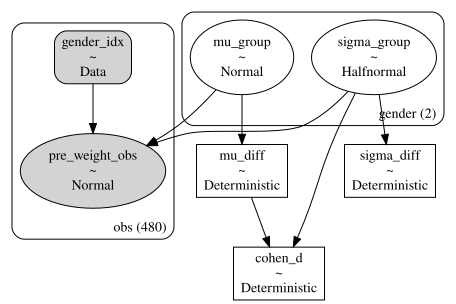

In [ ]:
with pm.Model(coords=coords_food_gender) as food_gender_separate_sigma_model:
    # Data
    gender = pm.Data("gender_idx", gender_idx, dims="obs")
    # Priors
    mu_group = pm.Normal("mu_group", mu=72.0, sigma=15.0, dims="gender")
    sigma_group = pm.HalfNormal("sigma_group", sigma=12.0, dims="gender" )

    # Raw effect size
    mu_diff = pm.Deterministic("mu_diff", mu_group[1] - mu_group[0] )

    sigma_diff = pm.Deterministic("sigma_diff", sigma_group[1] - sigma_group[0])
    separate_sigma_ratio = idata_food_gender_separate.posterior["sigma_ratio"].values.ravel()

    # Normalized effect size
    cohen_d = pm.Deterministic( "cohen_d", mu_diff / pm.math.sqrt((sigma_group[0]**2
                                                           + sigma_group[1]**2) / 2))
    # Likelihood
    pre_weight_obs = pm.Normal("pre_weight_obs", mu=mu_group[gender],
                              sigma=sigma_group[gender], observed=pre_weight, dims="obs")

pm.model_to_graphviz(food_gender_separate_sigma_model)

### Prior predictive check

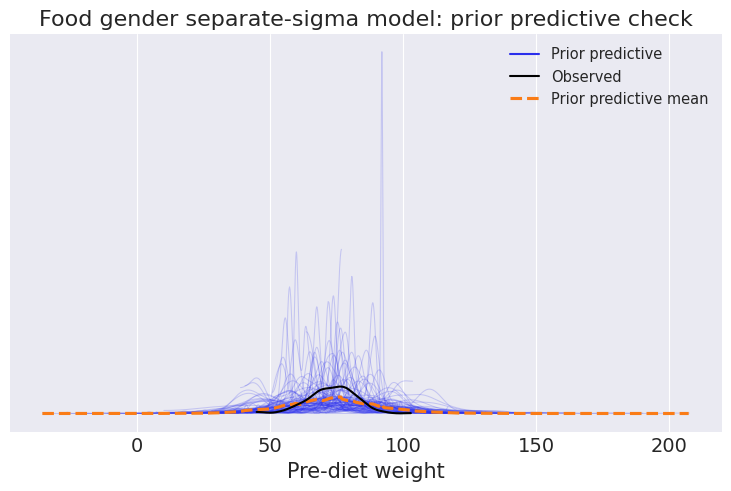

In [ ]:
with food_gender_separate_sigma_model:
    idata_food_gender_separate_prior = pm.sample_prior_predictive(
        samples=1000,
        random_seed=random_seed
    )

az.plot_ppc(
    idata_food_gender_separate_prior,
    group="prior",
    observed=True,
    num_pp_samples=100,
    random_seed=random_seed
)

plt.title("Food gender separate-sigma model: prior predictive check")
plt.xlabel("Pre-diet weight")
plt.show()

### Sample posterior

In [ ]:
with food_gender_separate_sigma_model:
    idata_food_gender_separate = pm.sample(
        draws=1000,
        chains=4,
        random_seed=random_seed
    )

idata_food_gender_separate.extend(idata_food_gender_separate_prior)

idata_food_gender_separate

Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data

### Diagnostics

/tmp/ipykernel_2651/2154475414.py:13: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=1.0)


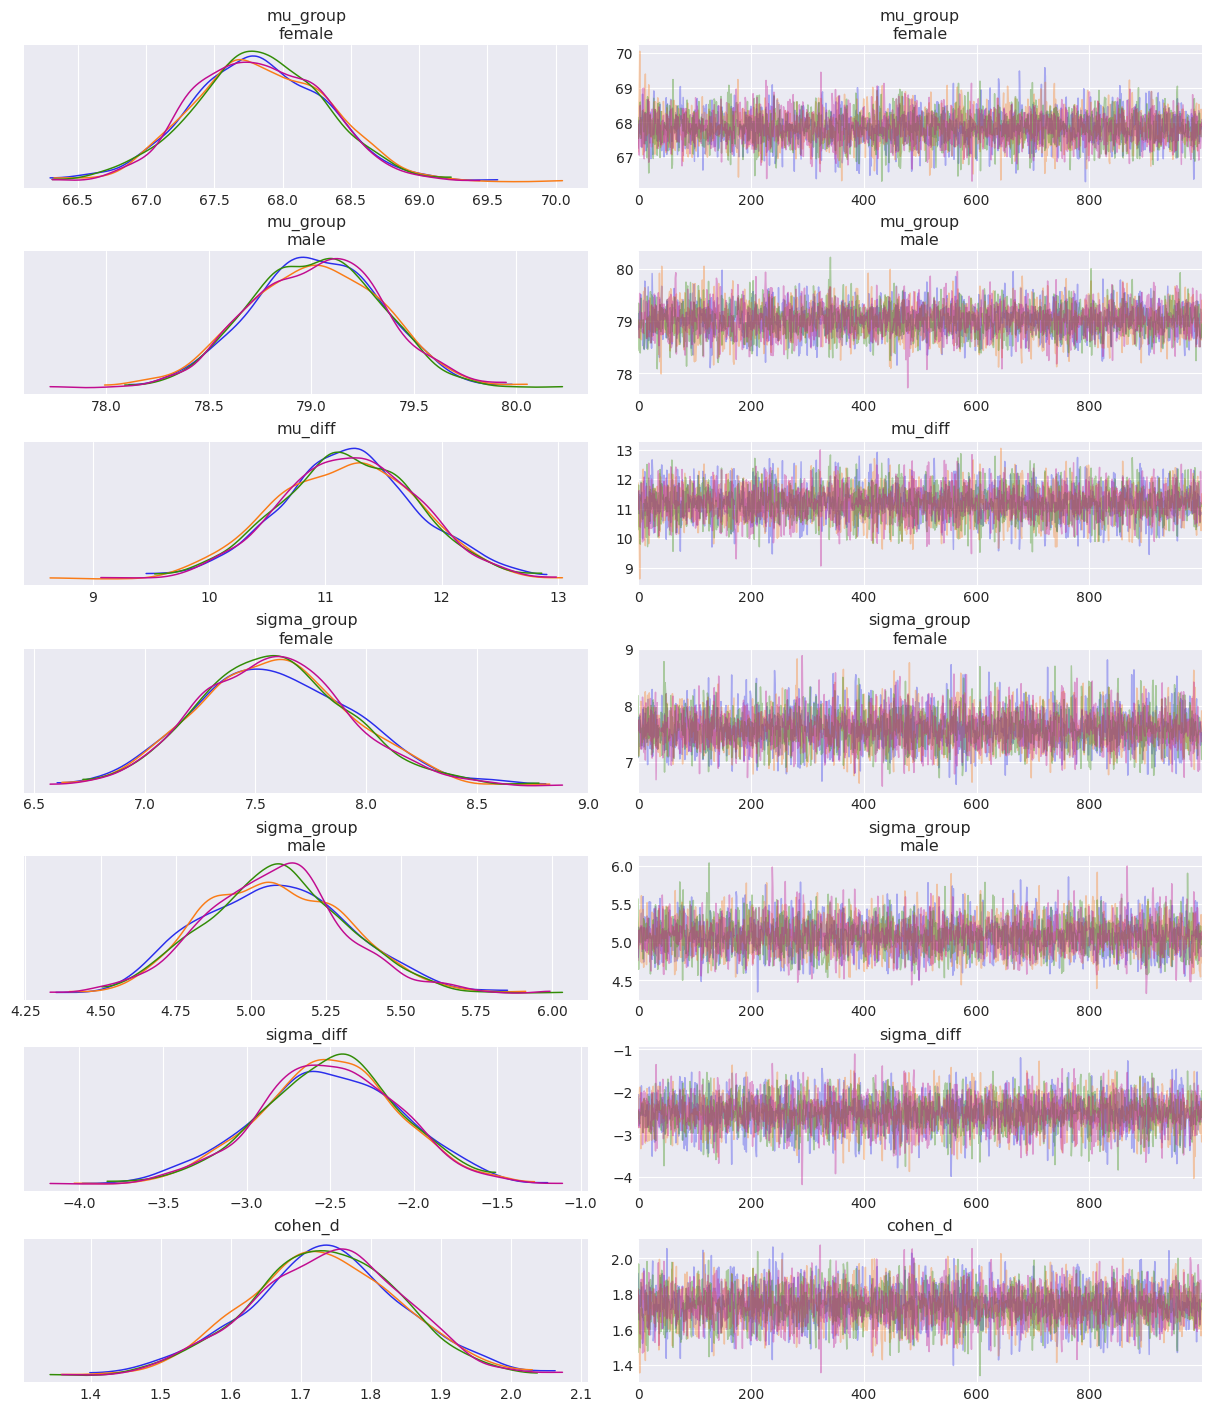

Number of divergences: 0


In [ ]:
az.summary(
    idata_food_gender_separate,
    var_names=["mu_group", "mu_diff", "sigma_group", "sigma_diff", "cohen_d"],
    kind="diagnostics"
)

az.plot_trace(
    idata_food_gender_separate,
    var_names=["mu_group", "mu_diff", "sigma_group", "sigma_diff", "cohen_d"],
    compact=False
)

plt.subplots_adjust(hspace=1.0)
plt.show()

food_gender_separate_divergences = idata_food_gender_separate.sample_stats["diverging"].sum().values
print(f"Number of divergences: {food_gender_separate_divergences}")

### Posterior predictive check

Output()

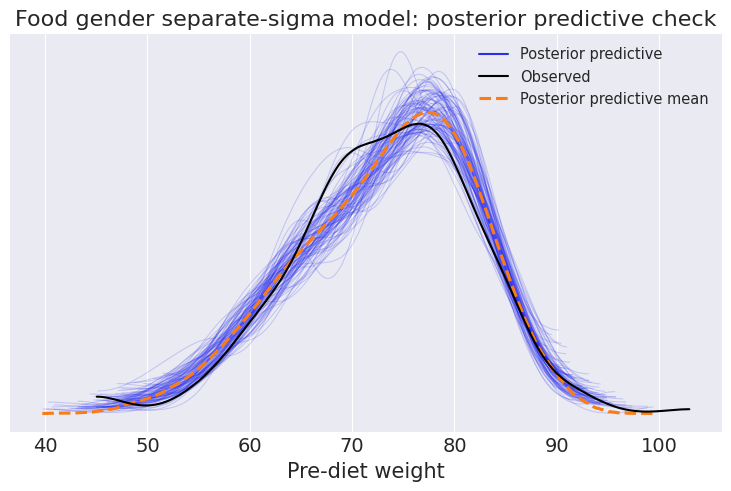

In [ ]:
with food_gender_separate_sigma_model:
    idata_food_gender_separate = pm.sample_posterior_predictive(
        idata_food_gender_separate,
        var_names=["pre_weight_obs"],
        random_seed=random_seed,
        extend_inferencedata=True
    )

az.plot_ppc(
    idata_food_gender_separate,
    group="posterior",
    observed=True,
    num_pp_samples=100,
    random_seed=random_seed
)

plt.title("Food gender separate-sigma model: posterior predictive check")
plt.xlabel("Pre-diet weight")
plt.show()

The separate-sigma model does not assume that both gender groups have the same spread. When the posterior predictive distribution is plotted for all observations together, it combines two group-specific Normal distributions. This mixture can look skewed even though each group is modeled with a Normal likelihood.

### Posterior comparison: shared sigma versus separate sigma

In [ ]:
shared_mu_diff = idata_food_gender_shared.posterior["mu_diff"].values.ravel()
separate_mu_diff = idata_food_gender_separate.posterior["mu_diff"].values.ravel()

shared_cohen_d = idata_food_gender_shared.posterior["cohen_d"].values.ravel()
separate_cohen_d = idata_food_gender_separate.posterior["cohen_d"].values.ravel()

separate_sigma_diff = idata_food_gender_separate.posterior["sigma_diff"].values.ravel()
separate_sigma_ratio = idata_food_gender_separate.posterior["sigma_ratio"].values.ravel()

unequal_variance_summary = pd.DataFrame([
    {
        "model": "shared sigma",
        "quantity": "mu_diff",
        "posterior mean": shared_mu_diff.mean(),
        "HDI low": az.hdi(shared_mu_diff, hdi_prob=HDI_MASS)[0],
        "HDI high": az.hdi(shared_mu_diff, hdi_prob=HDI_MASS)[1],
    },
    {
        "model": "separate sigma",
        "quantity": "mu_diff",
        "posterior mean": separate_mu_diff.mean(),
        "HDI low": az.hdi(separate_mu_diff, hdi_prob=HDI_MASS)[0],
        "HDI high": az.hdi(separate_mu_diff, hdi_prob=HDI_MASS)[1],
    },
    {
        "model": "separate sigma",
        "quantity": "sigma_diff: male - female",
        "posterior mean": separate_sigma_diff.mean(),
        "HDI low": az.hdi(separate_sigma_diff, hdi_prob=HDI_MASS)[0],
        "HDI high": az.hdi(separate_sigma_diff, hdi_prob=HDI_MASS)[1],
    },
    {
        "model": "separate sigma",
        "quantity": "sigma_ratio: male / female",
        "posterior mean": separate_sigma_ratio.mean(),
        "HDI low": az.hdi(separate_sigma_ratio, hdi_prob=HDI_MASS)[0],
        "HDI high": az.hdi(separate_sigma_ratio, hdi_prob=HDI_MASS)[1],
    },
])

unequal_variance_summary.style.format({
    "posterior mean": "{:.3f}",
    "HDI low": "{:.3f}",
    "HDI high": "{:.3f}",
})

,model,quantity,posterior mean,HDI low,HDI high
0,shared sigma,mu_diff,11.182,10.097,12.392
1,separate sigma,mu_diff,11.193,10.061,12.287
2,separate sigma,sigma_diff: male - female,-2.508,-3.285,-1.701
3,separate sigma,sigma_ratio: male / female,0.671,0.587,0.750


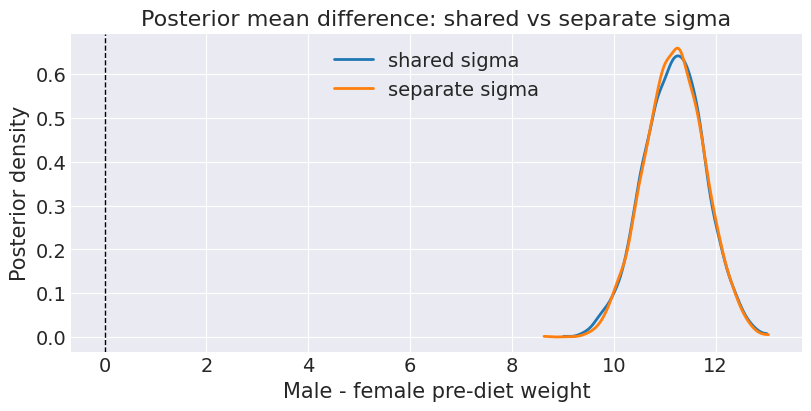

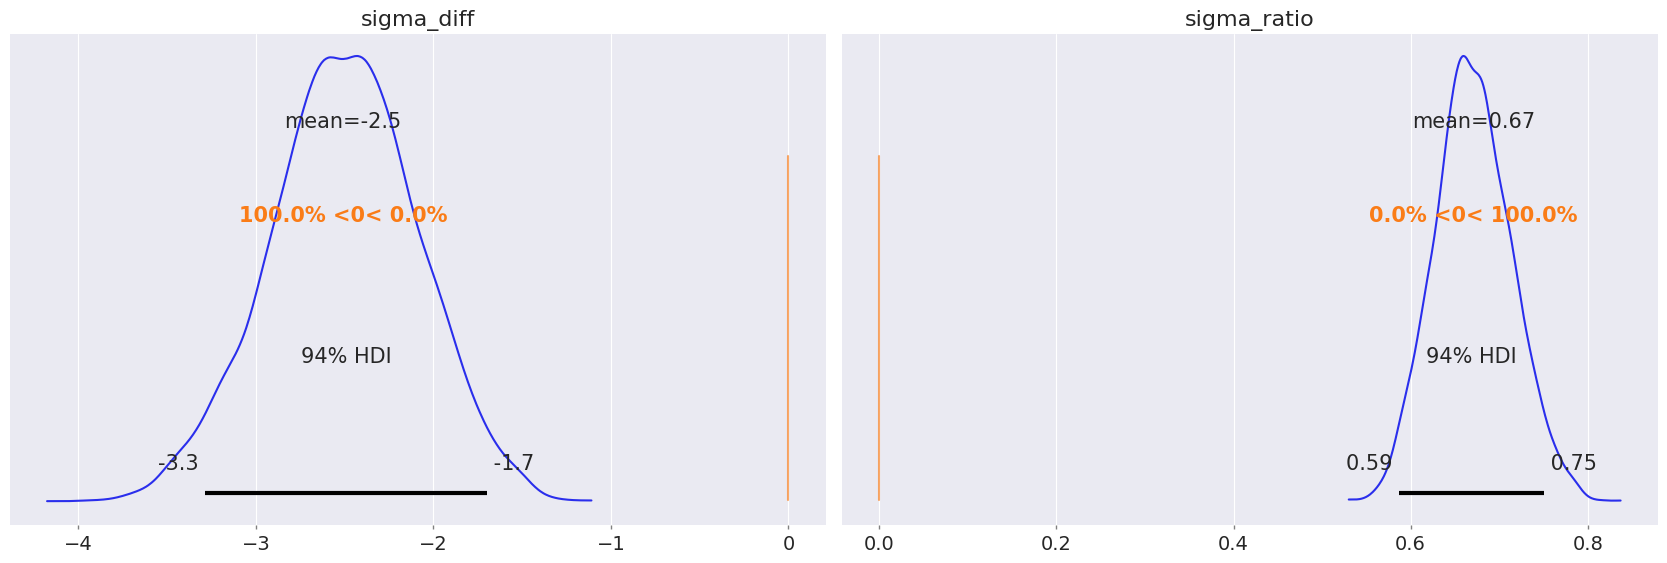

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

az.plot_kde(
    shared_mu_diff,
    ax=ax,
    plot_kwargs={"linewidth": 2, "color": BAYESIAN_COLOR},
    label="shared sigma"
)

az.plot_kde(
    separate_mu_diff,
    ax=ax,
    plot_kwargs={"linewidth": 2, "color": MODEL_COMPARISON_COLOR},
    label="separate sigma"
)

ax.axvline(0, color=NULL_COLOR, linestyle="--", linewidth=1)
ax.set_xlabel("Male - female pre-diet weight")
ax.set_ylabel("Posterior density")
ax.set_title("Posterior mean difference: shared vs separate sigma")
ax.legend()
plt.show()

az.plot_posterior(
    idata_food_gender_separate,
    var_names=["sigma_diff", "sigma_ratio"],
    ref_val=0,
    hdi_prob=HDI_MASS
)

plt.show()

## Final summary

In [ ]:
final_summary = pd.DataFrame([
    {
        "section": "One continuous outcome",
        "dataset": "Food diet",
        "model/test": "Bayesian Normal model",
        "main quantity": "mu and sigma of pre-diet weight",
    },
    {
        "section": "Paired data",
        "dataset": "Food diet",
        "model/test": "Bayesian paired Normal model",
        "main quantity": "mean change after - before",
    },
    {
        "section": "Paired frequentist comparison",
        "dataset": "Food diet",
        "model/test": "Paired t-test / Wilcoxon",
        "main quantity": "mean paired change and p-value",
    },
    {
        "section": "Robust model",
        "dataset": "Food diet",
        "model/test": "Student-t likelihood",
        "main quantity": "mu_change, sigma_change, nu",
    },
    {
        "section": "Independent groups",
        "dataset": "Food diet",
        "model/test": "Bayesian Normal group model",
        "main quantity": "male - female pre-diet weight difference",
    },
    {
        "section": "Independent frequentist comparison",
        "dataset": "Food diet",
        "model/test": "Pooled t-test / Welch t-test / Mann-Whitney",
        "main quantity": "mean difference and p-value",
    },
    {
        "section": "Unequal variances",
        "dataset": "Food diet",
        "model/test": "Separate-sigma Bayesian model",
        "main quantity": "group-specific sigma values",
    },
])

display(final_summary)

,section,dataset,model/test,main quantity
0,One continuous outcome,Food diet,Bayesian Normal model,mu and sigma of pre-diet weight
1,Paired data,Food diet,Bayesian paired Normal model,mean change after - before
2,Paired frequentist comparison,Food diet,Paired t-test / Wilcoxon,mean paired change and p-value
3,Robust model,Food diet,Student-t likelihood,"mu_change, sigma_change, nu"
4,Independent groups,Food diet,Bayesian Normal group model,male - female pre-diet weight difference
5,Independent frequentist comparison,Food diet,Pooled t-test / Welch t-test / Mann-Whitney,mean difference and p-value
6,Unequal variances,Food diet,Separate-sigma Bayesian model,group-specific sigma values
